# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Muhamad Alif Ramadhan
- Email: muhamadalifram@gmail.com
- Id Dicoding: malifram

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

### Menyiapkan data yang akan diguankan

In [ ]:
df = pd.read_csv('/content/data_student.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Sebuah dataset yang dibuat oleh institusi perguruan tinggi (didapatkan dari beberapa database terpisah) yang berkaitan dengan terdaftarnya siswa-siswa dalam berbagai program sarjana, seperti agronomi, desain, pendidikan, keperawatan, jurnalisme, manajemen, layanan sosial, dan teknologi. Dataset ini mencakup informasi yang diketahui pada saat pendaftaran siswa (jalur akademis, demografi, dan faktor sosial-ekonomi) serta kinerja akademis siswa pada akhir semester pertama dan kedua. Data ini digunakan untuk membangun model klasifikasi untuk memprediksi siswa yang akan drop out dan keberhasilan akademis mereka.

Dataset ini terdiri dari 37 fitur dan 4424 baris data. Berikut adalah penjelasan untuk masing-masing fitur.

| Column name | Description |
| --- | --- |
|Marital status | Status pernikahan siswa. (kategorikal) 1 – Lajang; 2 – Nikah; 3 – Duda; 4 – Cerai; 5 –Bersama tanpa ikatan resmi; 6 – Terpisah secara resmi |
| Application mode | Metode masuk perguruan tinggi yang digunakan oleh siswa. (kategorikal) 1 - Tahap pertama - kontingen umum; 2 - Peraturan No. 612/93; 5 - Tahap pertama - kontingen khusus (Pulau Azores); 7 - Pemegang kursus tinggi lainnya; 10 - Peraturan No. 854-B/99; 15 - Mahasiswa internasional (sarjana); 16 - Tahap pertama - kontingen khusus (Pulau Madeira); 17 - Tahap kedua - kontingen umum; 18 - Tahap ketiga - kontingen umum; 26 - Peraturan No. 533-A/99, item b2) (Rencana Berbeda); 27 - Peraturan No. 533-A/99, item b3 (Lembaga Lain); 39 - Berusia di atas 23 tahun; 42 - Transfer; 43 - Perubahan jurusan; 44 - Pemegang diploma spesialisasi teknologi; 51 - Perubahan institusi/jurusan; 53 - Pemegang diploma siklus pendek; 57 - Perubahan institusi/jurusan (Internasional)|
|Application order | Urutan di mana siswa mendaftar (Numerikal) Application order (Antara 0 - pilihan pertama; dan 9 pilihan terakhir) |
|Course | Mata kuliah yang diambil oleh siswa. (Kategoris); 33 - Teknologi Produksi Bahan Bakar Nabati; 171 - Desain Animasi dan Multimedia; 8014 - Layanan Sosial (kehadiran malam); 9003 - Agronomi; 9070 - Desain Komunikasi; 9085 - Perawatan Hewan; 9119 - Teknik Informatika; 9130 - Peternakan Kuda; 9147 - Manajemen; 9238 - Layanan Sosial; 9254 - Pariwisata; 9500 - Keperawatan; 9556 - Kesehatan Gigi; 9670 - Manajemen Periklanan dan Pemasaran; 9773 - Jurnalisme dan Komunikasi; 9853 - Pendidikan Dasar; 9991 - Manajemen (kehadiran malam)|
|Daytime/evening attendance | Apakah siswa menghadiri kelas siang atau malam. (Kategoris) 1 - siang; 0 - malam |
|Previous qualification| Kualifikasi yang diperoleh oleh siswa sebelum mendaftar di perguruan tinggi. (Kategoris) 1 - Pendidikan Sekunder; 2 - Pendidikan Tinggi - gelar sarjana; 3 - Pendidikan Tinggi - gelar; 4 - Pendidikan Tinggi - gelar magister; 5 - Pendidikan Tinggi - gelar doktor; 6 - Frekuensi pendidikan tinggi; 9 - Tahun ke-12 sekolah - tidak selesai; 10 - Tahun ke-11 sekolah - tidak selesai; 12 - Lainnya - Tahun ke-11 sekolah; 14 - Tahun ke-10 sekolah; 15 - Tahun ke-10 sekolah - tidak selesai; 19 - Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara; 38 - Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara; 39 - Kursus Spesialisasi Teknologi; 40 - Pendidikan Tinggi - gelar (Siklus 1); 42 - Kursus Teknis Tinggi Profesional; 43 - Pendidikan Tinggi - gelar magister (Siklus 2) |
|Previous qualification (grade) | Nilai dari kualifikasi sebelumnya (antara 0 dan 200) |
|Nacionality |  Kebangsaan siswa. (Kategoris) 1 - Portugis; 2 - Jerman; 6 - Spanyol; 11 - Italia; 13 - Belanda; 14 - Inggris; 17 - Lithuania; 21 - Angola; 22 - Cape Verde; 24 - Guinea; 25 - Mozambik; 26 - Santomean; 32 - Turki; 41 - Brasil; 62 - Rumania; 100 - Moldova (Republik); 101 - Meksiko; 103 - Ukraina; 105 - Rusia; 108 - Kuba; 109 - Kolombia |
|Mother's qualification | Kualifikasi ibu siswa. (Kategoris) 1 - Pendidikan Sekunder - Tahun ke-12 sekolah atau Setara; 2 - Pendidikan Tinggi - gelar sarjana; 3 - Pendidikan Tinggi - gelar; 4 - Pendidikan Tinggi - gelar magister; 5 - Pendidikan Tinggi - gelar doktor; 6 - Frekuensi Pendidikan Tinggi; 9 - Tahun ke-12 sekolah - Tidak Selesai; 10 - Tahun ke-11 sekolah - Tidak Selesai; 11 - Tahun ke-7 (Lama); 12 - Lainnya - Tahun ke-11 sekolah; 14 - Tahun ke-10 sekolah; 18 - Kursus Perdagangan Umum; 19 - Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara; 22 - Kursus Teknis-Profesional; 26 - Tahun ke-7 sekolah; 27 - Siklus 2 kursus SMA umum; 29 - Tahun ke-9 sekolah - Tidak Selesai; 30 - Tahun ke-8 sekolah; 34 - Tidak diketahui; 35 - Tidak bisa membaca atau menulis; 36 - Bisa membaca tanpa memiliki tahun ke-4 sekolah; 37 - Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau setara; 38 - Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara; 39 - Kursus Spesialisasi Teknologi; 40 - Pendidikan Tinggi - gelar (Siklus 1); 41 - Kursus Studi Tinggi Khusus; 42 - Kursus Teknis Tinggi Profesional; 43 - Pendidikan Tinggi - gelar magister (Siklus 2); 44 - Pendidikan Tinggi - gelar doktor (Siklus 3) |
|Father's qualification | Kualifikasi ayah siswa. (Kategoris) 1 - Pendidikan Sekunder - Tahun ke-12 sekolah atau Setara; 2 - Pendidikan Tinggi - gelar sarjana; 3 - Pendidikan Tinggi - gelar; 4 - Pendidikan Tinggi - gelar magister; 5 - Pendidikan Tinggi - gelar doktor; 6 - Frekuensi Pendidikan Tinggi; 9 - Tahun ke-12 sekolah - Tidak Selesai; 10 - Tahun ke-11 sekolah - Tidak Selesai; 11 - Tahun ke-7 (Lama); 12 - Lainnya - Tahun ke-11 sekolah; 13 - Kursus SMA komplementer tahun ke-2; 14 - Tahun ke-10 sekolah; 18 - Kursus Perdagangan Umum; 19 - Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara; 20 - Kursus SMA Komplementer; 22 - Kursus Teknis-Profesional; 25 - Kursus SMA Komplementer - tidak selesai; 26 - Tahun ke-7 sekolah; 27 - Siklus 2 kursus SMA umum; 29 - Tahun ke-9 sekolah - Tidak Selesai; 30 - Tahun ke-8 sekolah; 31 - Umum Administrasi dan Kursus Perdagangan; 33 - Akuntansi Tambahan dan Administrasi; 34 - Tidak diketahui; 35 - Tidak bisa membaca atau menulis; 36 - Bisa membaca tanpa memiliki tahun ke-4 sekolah; 37 - Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau setara; 38 - Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara; 39 - Kursus Spesialisasi Teknologi; 40 - Pendidikan Tinggi - gelar (Siklus 1); 41 - Kursus Studi Tinggi Khusus; 42 - Kursus Teknis Tinggi Profesional; 43 - Pendidikan Tinggi - gelar magister (Siklus 2); 44 - Pendidikan Tinggi - gelar doktor (Siklus 3) |
| Mother's occupation | Pekerjaan ibu siswa. (Kategoris) 0 - Siswa 1 - Wakil Kekuasaan Legislatif dan Badan Eksekutif, Direktur, Manajer Eksekutif dan Direktur 2 - Spesialis dalam Aktivitas Intelektual dan Ilmiah 3 - Teknisi dan Profesi Tingkat Menengah 4 - Staf Administrasi 5 - Pelayanan Personal, Pekerja Keamanan dan Keselamatan, serta Penjual 6 - Petani dan Tenaga Kerja Terampil di Pertanian, Perikanan, dan Kehutanan 7 - Tenaga Kerja Terampil di Industri, Konstruksi, dan Pengrajin 8 - Operator Pemasangan dan Mesin serta Pekerja Perakitan 9 - Tenaga Kerja Terampil 10 - Profesi Angkatan Bersenjata 90 - Situasi Lainnya 99 - (kosong) 122 - Profesional Kesehatan 123 - Guru 125 - Spesialis dalam teknologi informasi dan komunikasi (TIK) 131 - Teknisi dan Profesi Tingkat Menengah dalam Ilmu Pengetahuan dan Teknik 132 - Teknisi dan Profesional, tingkat menengah dari kesehatan 134 - Teknisi tingkat menengah dari layanan hukum, sosial, olahraga, budaya, dan sejenisnya 141 - Pekerja kantor, sekretaris umum, dan operator pengolahan data 143 - Operator data, akuntansi, statistik, layanan keuangan, dan yang terkait dengan registrasi 144 - Staf dukungan administratif lainnya 151 - Pekerja layanan personal 152 - Penjual 153 - Pekerja perawatan pribadi dan sejenisnya 171 - Tenaga kerja terampil dalam konstruksi dan sejenisnya, kecuali tukang listrik 173 - Tenaga kerja terampil dalam percetakan, pembuatan instrumen presisi, perhiasan, pengrajin, dan sejenisnya 175 - Tenaga kerja di bidang pengolahan makanan, kayu, pakaian, dan industri serta kerajinan lainnya 191 - Pekerja pembersihan 192 - Tenaga kerja tidak terampil di pertanian, produksi hewan, perikanan, dan kehutanan 193 - Tenaga kerja tidak terampil di industri ekstraktif, konstruksi, manufaktur, dan transportasi 194 - Asisten persiapan makanan |
| Father's occupation | Pekerjaan ayah siswa. (Kategoris) 0 - Siswa 1 - Wakil Kekuasaan Legislatif dan Badan Eksekutif, Direktur, Manajer Eksekutif dan Direktur 2 - Spesialis dalam Aktivitas Intelektual dan Ilmiah 3 - Teknisi dan Profesi Tingkat Menengah 4 - Staf Administrasi 5 - Pelayanan Personal, Pekerja Keamanan dan Keselamatan, serta Penjual 6 - Petani dan Tenaga Kerja Terampil di Pertanian, Perikanan, dan Kehutanan 7 - Tenaga Kerja Terampil di Industri, Konstruksi, dan Pengrajin 8 - Operator Pemasangan dan Mesin serta Pekerja Perakitan 9 - Tenaga Kerja Terampil 10 - Profesi Angkatan Bersenjata 90 - Situasi Lainnya 99 - (kosong) 101 - Perwira Angkatan Bersenjata 102 - Sersan Angkatan Bersenjata 103 - Personel Angkatan Bersenjata Lainnya 112 - Direktur Layanan Administratif dan Komersial 114 - Direktur Hotel, Restoran, Perdagangan, dan Layanan Lainnya 121 - Spesialis dalam ilmu fisika, matematika, teknik, dan teknik terkait 122 - Profesional Kesehatan 123 - Guru 124 - Spesialis dalam keuangan, akuntansi, organisasi administratif, hubungan publik, dan komersial 131 - Teknisi dan Profesi Tingkat Menengah dalam Ilmu Pengetahuan dan Teknik 132 - Teknisi dan Profesional, tingkat menengah dari kesehatan 134 - Teknisi tingkat menengah dari layanan hukum, sosial, olahraga, budaya, dan sejenisnya 135 - Teknisi Teknologi Informasi dan Komunikasi 141 - Pekerja kantor, sekretaris umum, dan operator pengolahan data 143 - Operator data, akuntansi, statistik, layanan keuangan, dan yang terkait dengan registrasi 144 - Staf dukungan administratif lainnya 151 - Pekerja layanan personal 152 - Penjual 153 - Pekerja perawatan pribadi dan sejenisnya 154 - Personil layanan perlindungan dan keamanan 161 - Petani berorientasi pasar dan tenaga kerja pertanian terampil dan produksi hewan 163 - Petani, pemelihara hewan, nelayan, pemburu, dan pengumpul, untuk pemenuhan kebutuhan 171 - Tenaga kerja terampil dalam konstruksi dan sejenisnya, kecuali tukang listrik 172 - Tenaga kerja terampil dalam logamurgi, permesinan logam, dan sejenisnya 174 - Tenaga kerja terampil dalam listrik dan elektronika 175 - Tenaga kerja di bidang pengolahan makanan, kayu, pakaian, dan industri serta kerajinan lainnya 181 - Operator pabrik dan mesin tetap 182 - Pekerja perakitan 183 - Pengemudi kendaraan dan operator peralatan mobile 192 - Tenaga kerja tidak terampil di pertanian, produksi hewan, perikanan, dan kehutanan 193 - Tenaga kerja tidak terampil di industri ekstraktif, konstruksi, manufaktur, dan transportasi 194 - Asisten persiapan makanan 195 - Pedagang jalanan (kecuali makanan) dan penyedia layanan jalanan |
| Admission grade | Nilai masuk (antara 0 dan 200) |
| Displaced | Apakah siswa adalah orang yang terdampak. (Kategoris) 1 – ya 0 – tidak |
| Educational special needs | Apakah siswa memiliki kebutuhan pendidikan khusus. (Kategoris) 1 – ya 0 – tidak |
| Debtor | Apakah siswa adalah peminjam. (Kategoris) 1 – ya 0 – tidak |
| Tuition fees up to date | Apakah biaya kuliah siswa sudah terbayar. (Kategoris) 1 – ya 0 – tidak |
| Gender | Jenis kelamin siswa. (Kategoris) 1 – laki-laki 0 – perempuan |
| Scholarship holder | Apakah siswa adalah penerima beasiswa. (Kategoris) 1 – ya 0 – tidak |
| Age at enrollment | Usia siswa pada saat pendaftaran. (Numerik) |
| International | Apakah siswa adalah mahasiswa internasional. (Kategoris) 1 – ya 0 – tidak |
| Curricular units 1st sem (credited) | Jumlah unit kurikuler yang diakui oleh siswa di semester pertama. (Numerik) |
| Curricular units 1st sem (enrolled) | Jumlah unit kurikuler yang diambil oleh siswa di semester pertama. (Numerik) |
| Curricular units 1st sem (evaluations) | Jumlah unit kurikuler yang dievaluasi oleh siswa di semester pertama. (Numerik) |
| Curricular units 1st sem (approved) | Jumlah unit kurikuler yang disetujui oleh siswa di semester pertama. (Numerik) |
| Curricular units 1st sem (grade) | Jumlah unit kurikuler yang dinilai oleh siswa dan diterima pada semester pertama. (Numerik) |
| Curricular units 1st sem (without evaluations) | Jumlah unit kurikuler yang diambil oleh siswa pada semester pertama tanpa dinilai. (Numerik) |
| Curricular units 2nd sem (credited) | Jumlah unit kurikuler yang diakui oleh siswa pada semester kedua. (Numerik) |
| Curricular units 2nd sem (enrolled) | Jumlah unit kurikuler yang diambil oleh siswa pada semester kedua. (Numerik) |
| Curricular units 2nd sem (evaluations) | Jumlah unit kurikuler yang dievaluasi oleh siswa pada semester kedua. (Numerik) |
| Curricular units 2nd sem (approved) | Jumlah unit kurikuler yang disetujui atau diterima oleh siswa pada semester kedua. (Numerik) |
| Curricular units 2nd sem (grade) | Jumlah unit kurikuler yang dinilai dan diterima oleh siswa pada semester kedua. (Numerik) |
| Curricular units 2nd sem (without evaluations) | Jumlah unit kurikuler yang diambil oleh siswa pada semester kedua tanpa dinilai. (Numerik) |
| Unemployment_rate | Tingkat pengangguran, yakni persentase dari jumlah orang yang tidak memiliki pekerjaan dalam populasi tertentu. (Numerik) |
| Inflation_rate | Tingkat inflasi, yang mengukur persentase kenaikan harga barang dan jasa dalam suatu periode waktu. (Numerik) |
| GDP | Gross Domestic Product (PDB), yakni nilai total semua barang dan jasa yang dihasilkan oleh suatu negara dalam satu tahun. (Numerik) |
| Status | Apakah mahasiswa tersebut _Dropout_, _Graduate_, ataupun _Enrolled_ (kategorikal) |


# Data Cleaning

In [ ]:
numerical_feat = [
    "Application_order", "Age_at_enrollment", "Admission_grade", "Curricular_units_1st_sem_credited", "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_evaluations", "Curricular_units_1st_sem_approved", "Curricular_units_1st_sem_grade",
    "Curricular_units_1st_sem_without_evaluations", "Curricular_units_2nd_sem_credited", "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_evaluations", "Curricular_units_2nd_sem_approved", "Curricular_units_2nd_sem_grade",
    "Curricular_units_2nd_sem_without_evaluations", "Previous_qualification_grade", "Unemployment_rate", "Inflation_rate", "GDP"
]

categorical_feat = [
    category_feat for category_feat in df.columns[:-1] if category_feat not in numerical_feat
]
categorical_feat

['Marital_status',
 'Application_mode',
 'Course',
 'Daytime_evening_attendance',
 'Previous_qualification',
 'Nacionality',
 'Mothers_qualification',
 'Fathers_qualification',
 'Mothers_occupation',
 'Fathers_occupation',
 'Displaced',
 'Educational_special_needs',
 'Debtor',
 'Tuition_fees_up_to_date',
 'Gender',
 'Scholarship_holder',
 'International']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [ ]:
df[numerical_feat].describe(include='all')

,Application_order,Age_at_enrollment,Admission_grade,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Previous_qualification_grade,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.727848,23.265145,126.978119,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,132.613314,11.566139,1.228029,0.001969
std,1.313793,7.587816,14.482001,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,13.188332,2.663850,1.382711,2.269935
min,0.000000,17.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,7.600000,-0.800000,-4.060000
25%,1.000000,19.000000,117.900000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,125.000000,9.400000,0.300000,-1.700000
50%,1.000000,20.000000,126.100000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,133.100000,11.100000,1.400000,0.320000
75%,2.000000,25.000000,134.800000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,140.000000,13.900000,2.600000,1.790000
max,9.000000,70.000000,190.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,190.000000,16.200000,3.700000,3.510000


In [ ]:
df[categorical_feat].describe(include='all')

,Marital_status,Application_mode,Course,Daytime_evening_attendance,Previous_qualification,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,International
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,8856.642631,0.890823,4.577758,1.873192,19.561935,22.275316,10.960895,11.032324,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,0.024864
std,0.605747,17.484682,2063.566416,0.311897,10.216592,6.914514,15.603186,15.343108,26.418253,25.263040,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,0.155729
min,1.000000,1.000000,33.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,9085.000000,1.000000,1.000000,1.000000,2.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,17.000000,9238.000000,1.000000,1.000000,1.000000,19.000000,19.000000,5.000000,7.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,39.000000,9556.000000,1.000000,1.000000,1.000000,37.000000,37.000000,9.000000,9.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,6.000000,57.000000,9991.000000,1.000000,43.000000,109.000000,44.000000,44.000000,194.000000,195.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
marital_status_dict = {
    1: "Lajang",
    2: "Nikah",
    3: "Duda",
    4: "Cerai",
    5: "Bersama tanpa ikatan resmi",
    6: "Terpisah secara resmi"
}

application_mode_dict = {
    1: "Tahap pertama - kontingen umum",
    2: "Peraturan No. 612/93",
    5: "Tahap pertama - kontingen khusus (Pulau Azores)",
    7: "Pemegang kursus tinggi lainnya",
    10: "Peraturan No. 854-B/99",
    15: "Mahasiswa internasional (sarjana)",
    16: "Tahap pertama - kontingen khusus (Pulau Madeira)",
    17: "Tahap kedua - kontingen umum",
    18: "Tahap ketiga - kontingen umum",
    26: "Peraturan No. 533-A/99, item b2) (Rencana Berbeda)",
    27: "Peraturan No. 533-A/99, item b3 (Lembaga Lain)",
    39: "Berusia di atas 23 tahun",
    42: "Transfer",
    43: "Perubahan jurusan",
    44: "Pemegang diploma spesialisasi teknologi",
    51: "Perubahan institusi/jurusan",
    53: "Pemegang diploma siklus pendek",
    57: "Perubahan institusi/jurusan (Internasional)"
}

course_dict = {
    33: "Teknologi Produksi Bahan Bakar Nabati",
    171: "Desain Animasi dan Multimedia",
    8014: "Layanan Sosial (kehadiran malam)",
    9003: "Agronomi",
    9070: "Desain Komunikasi",
    9085: "Perawatan Hewan",
    9119: "Teknik Informatika",
    9130: "Peternakan Kuda",
    9147: "Manajemen",
    9238: "Layanan Sosial",
    9254: "Pariwisata",
    9500: "Keperawatan",
    9556: "Kesehatan Gigi",
    9670: "Manajemen Periklanan dan Pemasaran",
    9773: "Jurnalisme dan Komunikasi",
    9853: "Pendidikan Dasar",
    9991: "Manajemen (kehadiran malam)"
}

daytime_evening_attendance_dict = {0:"Malam", 1:"Siang"}

prev_qualification_dict = {
    1: "Pendidikan Sekunder",
    2: "Pendidikan Tinggi - gelar sarjana",
    3: "Pendidikan Tinggi - gelar",
    4: "Pendidikan Tinggi - gelar magister",
    5: "Pendidikan Tinggi - gelar doktor",
    6: "Frekuensi pendidikan tinggi",
    9: "Tahun ke-12 sekolah - tidak selesai",
    10: "Tahun ke-11 sekolah - tidak selesai",
    12: "Lainnya - Tahun ke-11 sekolah",
    14: "Tahun ke-10 sekolah",
    15: "Tahun ke-10 sekolah - tidak selesai",
    19: "Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara",
    38: "Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara",
    39: "Kursus Spesialisasi Teknologi",
    40: "Pendidikan Tinggi - gelar (Siklus 1)",
    42: "Kursus Teknis Tinggi Profesional",
    43: "Pendidikan Tinggi - gelar magister (Siklus 2)"
}

nationality_dict = {
    1: "Portugis",
    2: "Jerman",
    6: "Spanyol",
    11: "Italia",
    13: "Belanda",
    14: "Inggris",
    17: "Lithuania",
    21: "Angola",
    22: "Cape Verde",
    24: "Guinea",
    25: "Mozambik",
    26: "Santomean",
    32: "Turki",
    41: "Brasil",
    62: "Rumania",
    100: "Moldova (Republik)",
    101: "Meksiko",
    103: "Ukraina",
    105: "Rusia",
    108: "Kuba",
    109: "Kolombia"
}

mother_qualification_dict = {
    1: "Pendidikan Sekunder - Tahun ke-12 sekolah atau Setara",
    2: "Pendidikan Tinggi - gelar sarjana",
    3: "Pendidikan Tinggi - gelar",
    4: "Pendidikan Tinggi - gelar magister",
    5: "Pendidikan Tinggi - gelar doktor",
    6: "Frekuensi Pendidikan Tinggi",
    9: "Tahun ke-12 sekolah - Tidak Selesai",
    10: "Tahun ke-11 sekolah - Tidak Selesai",
    11: "Tahun ke-7 (Lama)",
    12: "Lainnya - Tahun ke-11 sekolah",
    14: "Tahun ke-10 sekolah",
    18: "Kursus Perdagangan Umum",
    19: "Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara",
    22: "Kursus Teknis-Profesional",
    26: "Tahun ke-7 sekolah",
    27: "Siklus 2 kursus SMA umum",
    29: "Tahun ke-9 sekolah - Tidak Selesai",
    30: "Tahun ke-8 sekolah",
    34: "Tidak diketahui",
    35: "Tidak bisa membaca atau menulis",
    36: "Bisa membaca tanpa memiliki tahun ke-4 sekolah",
    37: "Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau setara",
    38: "Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara",
    39: "Kursus Spesialisasi Teknologi",
    40: "Pendidikan Tinggi - gelar (Siklus 1)",
    41: "Kursus Studi Tinggi Khusus",
    42: "Kursus Teknis Tinggi Profesional",
    43: "Pendidikan Tinggi - gelar magister (Siklus 2)",
    44: "Pendidikan Tinggi - gelar doktor (Siklus 3)"
}

father_qualification_dict = {
    1: "Pendidikan Sekunder - Tahun ke-12 sekolah atau Setara",
    2: "Pendidikan Tinggi - gelar sarjana",
    3: "Pendidikan Tinggi - gelar",
    4: "Pendidikan Tinggi - gelar magister",
    5: "Pendidikan Tinggi - gelar doktor",
    6: "Frekuensi Pendidikan Tinggi",
    9: "Tahun ke-12 sekolah - Tidak Selesai",
    10: "Tahun ke-11 sekolah - Tidak Selesai",
    11: "Tahun ke-7 (Lama)",
    12: "Lainnya - Tahun ke-11 sekolah",
    13: "Kursus SMA komplementer tahun ke-2",
    14: "Tahun ke-10 sekolah",
    18: "Kursus Perdagangan Umum",
    19: "Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara",
    20: "Kursus SMA Komplementer",
    22: "Kursus Teknis-Profesional",
    25: "Kursus SMA Komplementer - tidak selesai",
    26: "Tahun ke-7 sekolah",
    27: "Siklus 2 kursus SMA umum",
    29: "Tahun ke-9 sekolah - Tidak Selesai",
    30: "Tahun ke-8 sekolah",
    31: "Umum Administrasi dan Kursus Perdagangan",
    33: "Akuntansi Tambahan dan Administrasi",
    34: "Tidak diketahui",
    35: "Tidak bisa membaca atau menulis",
    36: "Bisa membaca tanpa memiliki tahun ke-4 sekolah",
    37: "Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau setara",
    38: "Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara",
    39: "Kursus Spesialisasi Teknologi",
    40: "Pendidikan Tinggi - gelar (Siklus 1)",
    41: "Kursus Studi Tinggi Khusus",
    42: "Kursus Teknis Tinggi Profesional",
    43: "Pendidikan Tinggi - gelar magister (Siklus 2)",
    44: "Pendidikan Tinggi - gelar doktor (Siklus 3)"
}

mother_occupation_dict = {
    0: "Siswa",
    1: "Wakil Kekuasaan Legislatif dan Badan Eksekutif, Direktur, Manajer Eksekutif dan Direktur",
    2: "Spesialis dalam Aktivitas Intelektual dan Ilmiah",
    3: "Teknisi dan Profesi Tingkat Menengah",
    4: "Staf Administrasi",
    5: "Pelayanan Personal, Pekerja Keamanan dan Keselamatan, serta Penjual",
    6: "Petani dan Tenaga Kerja Terampil di Pertanian, Perikanan, dan Kehutanan",
    7: "Tenaga Kerja Terampil di Industri, Konstruksi, dan Pengrajin",
    8: "Operator Pemasangan dan Mesin serta Pekerja Perakitan",
    9: "Tenaga Kerja Terampil",
    10: "Profesi Angkatan Bersenjata",
    90: "Situasi Lainnya",
    99: "(kosong)",
    122: "Profesional Kesehatan",
    123: "Guru",
    125: "Spesialis dalam teknologi informasi dan komunikasi (TIK)",
    131: "Teknisi dan Profesi Tingkat Menengah dalam Ilmu Pengetahuan dan Teknik",
    132: "Teknisi dan Profesional, tingkat menengah dari kesehatan",
    134: "Teknisi tingkat menengah dari layanan hukum, sosial, olahraga, budaya, dan sejenisnya",
    141: "Pekerja kantor, sekretaris umum, dan operator pengolahan data",
    143: "Operator data, akuntansi, statistik, layanan keuangan, dan yang terkait dengan registrasi",
    144: "Staf dukungan administratif lainnya",
    151: "Pekerja layanan personal",
    152: "Penjual",
    153: "Pekerja perawatan pribadi dan sejenisnya",
    171: "Tenaga kerja terampil dalam konstruksi dan sejenisnya, kecuali tukang listrik",
    173: "Tenaga kerja terampil dalam percetakan, pembuatan instrumen presisi, perhiasan, pengrajin, dan sejenisnya",
    175: "Tenaga kerja di bidang pengolahan makanan, kayu, pakaian, dan industri serta kerajinan lainnya",
    191: "Pekerja pembersihan",
    192: "Tenaga kerja tidak terampil di pertanian, produksi hewan, perikanan, dan kehutanan",
    193: "Tenaga kerja tidak terampil di industri ekstraktif, konstruksi, manufaktur, dan transportasi",
    194: "Asisten persiapan makanan"
}

father_occupation_dict = {
    0: "Siswa",
    1: "Wakil Kekuasaan Legislatif dan Badan Eksekutif, Direktur, Manajer Eksekutif dan Direktur",
    2: "Spesialis dalam Aktivitas Intelektual dan Ilmiah",
    3: "Teknisi dan Profesi Tingkat Menengah",
    4: "Staf Administrasi",
    5: "Pelayanan Personal, Pekerja Keamanan dan Keselamatan, serta Penjual",
    6: "Petani dan Tenaga Kerja Terampil di Pertanian, Perikanan, dan Kehutanan",
    7: "Tenaga Kerja Terampil di Industri, Konstruksi, dan Pengrajin",
    8: "Operator Pemasangan dan Mesin serta Pekerja Perakitan",
    9: "Tenaga Kerja Terampil",
    10: "Profesi Angkatan Bersenjata",
    90: "Situasi Lainnya",
    99: "(kosong)",
    101: "Perwira Angkatan Bersenjata",
    102: "Sersan Angkatan Bersenjata",
    103: "Personel Angkatan Bersenjata Lainnya",
    112: "Direktur Layanan Administratif dan Komersial",
    114: "Direktur Hotel, Restoran, Perdagangan, dan Layanan Lainnya",
    121: "Spesialis dalam ilmu fisika, matematika, teknik, dan teknik terkait",
    122: "Profesional Kesehatan",
    123: "Guru",
    124: "Spesialis dalam keuangan, akuntansi, organisasi administratif, hubungan publik, dan komersial",
    131: "Teknisi dan Profesi Tingkat Menengah dalam Ilmu Pengetahuan dan Teknik",
    132: "Teknisi dan Profesional, tingkat menengah dari kesehatan",
    134: "Teknisi tingkat menengah dari layanan hukum, sosial, olahraga, budaya, dan sejenisnya",
    135: "Teknisi Teknologi Informasi dan Komunikasi",
    141: "Pekerja kantor, sekretaris umum, dan operator pengolahan data",
    143: "Operator data, akuntansi, statistik, layanan keuangan, dan yang terkait dengan registrasi",
    144: "Staf dukungan administratif lainnya",
    151: "Pekerja layanan personal",
    152: "Penjual",
    153: "Pekerja perawatan pribadi dan sejenisnya",
    154: "Personil layanan perlindungan dan keamanan",
    161: "Petani berorientasi pasar dan tenaga kerja pertanian terampil dan produksi hewan",
    163: "Petani, pemelihara hewan, nelayan, pemburu, dan pengumpul, untuk pemenuhan kebutuhan",
    171: "Tenaga kerja terampil dalam konstruksi dan sejenisnya, kecuali tukang listrik",
    172: "Tenaga kerja terampil dalam logamurgi, permesinan logam, dan sejenisnya",
    174: "Tenaga kerja terampil dalam listrik dan elektronika",
    175: "Tenaga kerja di bidang pengolahan makanan, kayu, pakaian, dan industri serta kerajinan lainnya",
    181: "Operator pabrik dan mesin tetap",
    182: "Pekerja perakitan",
    183: "Pengemudi kendaraan dan operator peralatan mobile",
    192: "Tenaga kerja tidak terampil di pertanian, produksi hewan, perikanan, dan kehutanan",
    193: "Tenaga kerja tidak terampil di industri ekstraktif, konstruksi, manufaktur, dan transportasi",
    194: "Asisten persiapan makanan",
    195: "Pedagang jalanan (kecuali makanan) dan penyedia layanan jalanan"
}

displaced_dict = {0:"Tidak", 1:"Ya"}

educational_special_needs_dict = {0:"Tidak", 1:"Ya"}

debtor_dict = {0:"Tidak", 1:"Ya"}

tuition_fees_dict = {0:"Tidak", 1:"Ya"}

gender_dict = {0:"Perempuan", 1:"Laki-laki"}

scholarship_holder_dict = {0:"Tidak", 1:"Ya"}

international_dict = {0:"Tidak", 1:"Ya"}

In [ ]:
dict_list = [marital_status_dict, application_mode_dict, course_dict,
            daytime_evening_attendance_dict, prev_qualification_dict,
            nationality_dict, mother_qualification_dict, father_qualification_dict,
            mother_occupation_dict, father_occupation_dict, displaced_dict,
            educational_special_needs_dict, debtor_dict, tuition_fees_dict,
            gender_dict, scholarship_holder_dict, international_dict]

In [ ]:
def val_decoder(df, features, dicts):
    new_df = df.copy()
    for feature, mapping_dict in zip(features, dicts):
        new_df[feature] = new_df[feature].replace(mapping_dict)
    return new_df

In [ ]:
new_df = val_decoder(df, categorical_feat, dict_list)
new_df.head(20)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,Lajang,Tahap kedua - kontingen umum,5,Desain Animasi dan Multimedia,Siang,Pendidikan Sekunder,122.0,Portugis,Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) a...,Lainnya - Tahun ke-11 sekolah,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Lajang,Mahasiswa internasional (sarjana),1,Pariwisata,Siang,Pendidikan Sekunder,160.0,Portugis,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,Pendidikan Tinggi - gelar,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Lajang,Tahap pertama - kontingen umum,5,Desain Komunikasi,Siang,Pendidikan Sekunder,122.0,Portugis,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Lajang,Tahap kedua - kontingen umum,2,Jurnalisme dan Komunikasi,Siang,Pendidikan Sekunder,122.0,Portugis,Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) ata...,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Nikah,Berusia di atas 23 tahun,1,Layanan Sosial (kehadiran malam),Malam,Pendidikan Sekunder,100.0,Portugis,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) ata...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,Nikah,Berusia di atas 23 tahun,1,Manajemen (kehadiran malam),Malam,Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) a...,133.1,Portugis,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,Lajang,Tahap pertama - kontingen umum,1,Keperawatan,Siang,Pendidikan Sekunder,142.0,Portugis,Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) a...,Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) ata...,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,Lajang,Tahap ketiga - kontingen umum,4,Pariwisata,Siang,Pendidikan Sekunder,119.0,Portugis,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,Lajang,Tahap pertama - kontingen umum,3,Layanan Sosial,Siang,Pendidikan Sekunder,137.0,Rumania,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,Lajang,Tahap pertama - kontingen umum,1,Layanan Sosial,Siang,Pendidikan Sekunder,138.0,Portugis,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) a...,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [ ]:
new_df["Fathers_occupation"].unique()

array(['Tenaga Kerja Terampil', 'Teknisi dan Profesi Tingkat Menengah',
       'Tenaga Kerja Terampil di Industri, Konstruksi, dan Pengrajin',
       'Profesi Angkatan Bersenjata',
       'Pelayanan Personal, Pekerja Keamanan dan Keselamatan, serta Penjual',
       'Operator Pemasangan dan Mesin serta Pekerja Perakitan',
       'Staf Administrasi',
       'Wakil Kekuasaan Legislatif dan Badan Eksekutif, Direktur, Manajer Eksekutif dan Direktur',
       'Spesialis dalam Aktivitas Intelektual dan Ilmiah',
       'Spesialis dalam keuangan, akuntansi, organisasi administratif, hubungan publik, dan komersial',
       'Petani dan Tenaga Kerja Terampil di Pertanian, Perikanan, dan Kehutanan',
       'Siswa', 'Situasi Lainnya',
       'Tenaga kerja di bidang pengolahan makanan, kayu, pakaian, dan industri serta kerajinan lainnya',
       'Spesialis dalam ilmu fisika, matematika, teknik, dan teknik terkait',
       '(kosong)', 'Staf dukungan administratif lainnya',
       'Pedagang jalanan (kec

In [ ]:
new_df.describe(include="all")

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424,4424,4424.000000,4424,4424,4424,4424.000000,4424,4424,4424,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,6,18,NaN,17,2,17,NaN,21,29,34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Lajang,Tahap pertama - kontingen umum,NaN,Keperawatan,Siang,Pendidikan Sekunder,NaN,Portugis,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,3919,1708,NaN,766,3941,3717,NaN,4314,1069,1209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,NaN,NaN,1.727848,NaN,NaN,NaN,132.613314,NaN,NaN,NaN,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,NaN,NaN,1.313793,NaN,NaN,NaN,13.188332,NaN,NaN,NaN,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,95.000000,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,NaN,NaN,1.000000,NaN,NaN,NaN,125.000000,NaN,NaN,NaN,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,NaN,NaN,1.000000,NaN,NaN,NaN,133.100000,NaN,NaN,NaN,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,NaN,NaN,2.000000,NaN,NaN,NaN,140.000000,NaN,NaN,NaN,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [ ]:
new_df[numerical_feat].describe(include='all')

,Application_order,Age_at_enrollment,Admission_grade,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Previous_qualification_grade,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.727848,23.265145,126.978119,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,132.613314,11.566139,1.228029,0.001969
std,1.313793,7.587816,14.482001,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,13.188332,2.663850,1.382711,2.269935
min,0.000000,17.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,7.600000,-0.800000,-4.060000
25%,1.000000,19.000000,117.900000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,125.000000,9.400000,0.300000,-1.700000
50%,1.000000,20.000000,126.100000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,133.100000,11.100000,1.400000,0.320000
75%,2.000000,25.000000,134.800000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,140.000000,13.900000,2.600000,1.790000
max,9.000000,70.000000,190.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,190.000000,16.200000,3.700000,3.510000


In [ ]:
new_df.Status.value_counts()

,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


In [ ]:
new_df.isnull().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


Insight:
- Dataset tidak mengandung data duplikat maupun nilai yang kosong, sehingga tidak diperlukan pembersihan data lebih lanjut pada aspek ini.

- Setiap kolom telah diisi dengan data yang sesuai dan konsisten dengan deskripsinya.

- Distribusi pada variabel target (Status) tidak seimbang, yang berisiko menyebabkan model prediksi menjadi bias terhadap kelas mayoritas.

# Exploratory Data Analysis

In [ ]:
def cat_plot(df, features, segment_by=False, grid_axis='x'):
    height = len(features) * 4
    sns.set_palette("bright")

    fig, ax = plt.subplots(ncols=1, nrows=len(features), figsize=(14, height))
    if len(features) == 1:
        ax = [ax]
    for i, feature in enumerate(features):
        if segment_by:
            sns.countplot(data=df, y=feature, hue=segment_by, ax=ax[i])
            ax[i].set_title(f"{segment_by} by {feature}")
        else:
            sns.countplot(data=df, y=feature, ax=ax[i])
            ax[i].set_title(f"{feature}")

        # Tambahkan garis bantu grid
        if grid_axis == 'x':
            ax[i].xaxis.grid(True)
        elif grid_axis == 'y':
            ax[i].yaxis.grid(True)

    plt.tight_layout()
    plt.show()

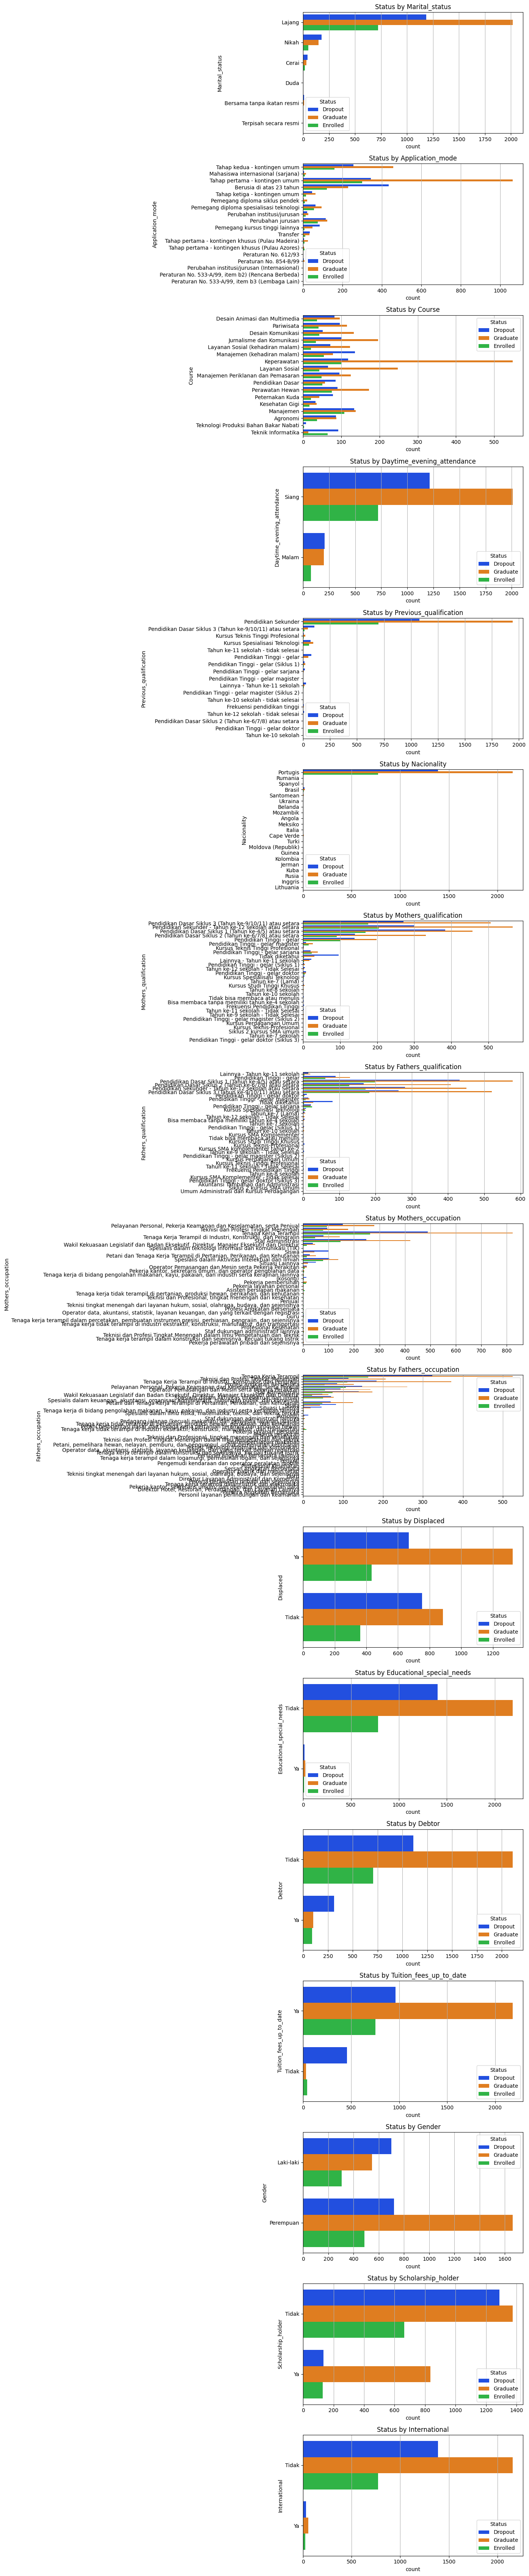

In [ ]:
cat_plot(new_df, categorical_feat, segment_by="Status")

Berdasarkan visualisasi distribusi status mahasiswa terhadap berbagai kategori, terlihat bahwa beberapa faktor memiliki pola yang cukup mencolok dalam kaitannya dengan tingkat dropout. Mahasiswa dengan status pernikahan tertentu, mode aplikasi, dan jenis kursus tertentu cenderung memiliki proporsi dropout yang lebih tinggi. Selain itu, mahasiswa yang tidak membayar biaya kuliah tepat waktu atau bukan penerima beasiswa juga menunjukkan angka dropout yang lebih besar. Faktor lain seperti jenis kelamin, status orang tua, latar belakang pendidikan sebelumnya, serta kebutuhan khusus juga tampak berpengaruh terhadap status akhir mahasiswa. Insight ini menggarisbawahi pentingnya dukungan finansial, akademik, dan sosial dalam menjaga keberlangsungan studi mahasiswa.

In [ ]:
def numerical_dis_plot(df, features, segment_by=False):
    height = len(features) * 4
    sns.set_palette("bright")

    fig, ax = plt.subplots(ncols=1, nrows=len(features), figsize=(10, height))
    for i, feature in enumerate(features):
        if segment_by:
            sns.boxplot(data=df, y=feature, hue=segment_by, ax=ax[i])
            ax[i].set_title(f"{segment_by} by {feature}")
        else:
            sns.boxplot(data=df, y=feature, ax=ax[i])
            ax[i].set_title(f"{feature}")
    plt.tight_layout()
    plt.show()

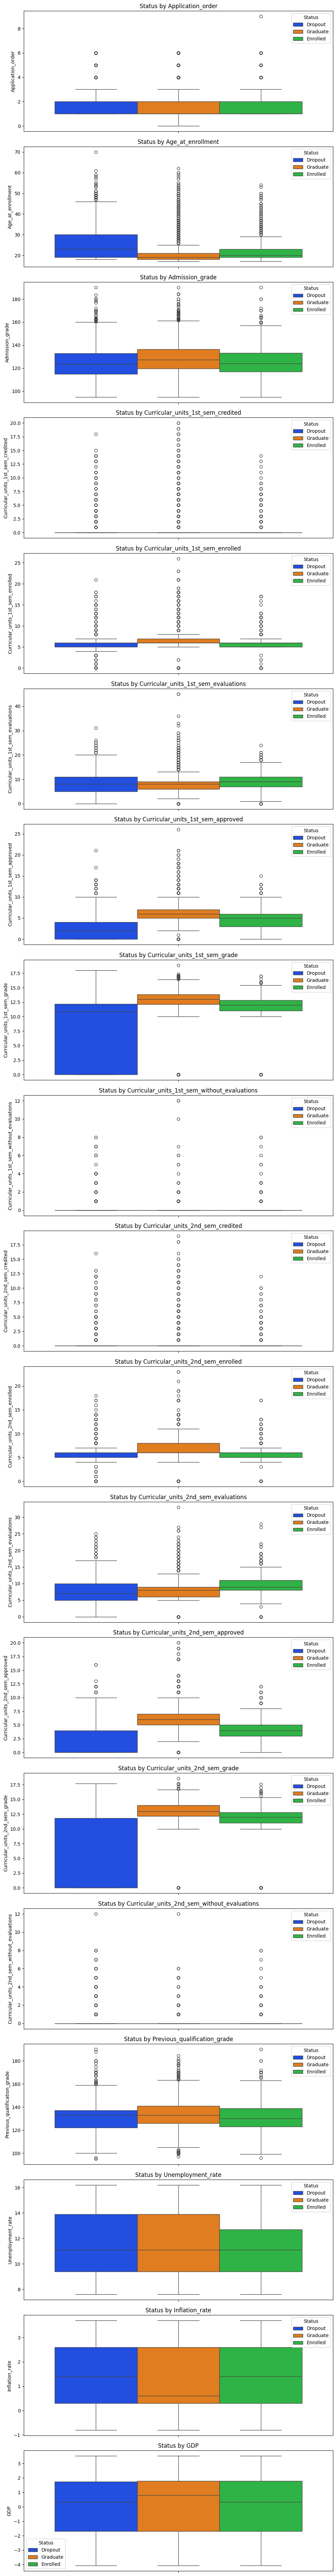

In [ ]:
numerical_dis_plot(new_df, numerical_feat, segment_by="Status")

Gambar tersebut menampilkan berbagai variabel yang terkait dengan status mahasiswa (Dropout, Graduate, Enrolled) dalam konteks pendidikan tinggi, termasuk faktor-faktor seperti usia saat pendaftaran (Age_at_enrollment), nilai masuk (Admission_grade), jumlah mata kuliah yang diambil dan lulus (Curricular_units), serta indikator ekonomi seperti tingkat pengangguran (Unemployment_rate) dan inflasi (Inflation_rate). Visualisasi menunjukkan distribusi dan hubungan antara variabel-variabel ini dengan status mahasiswa misalnya, mahasiswa dengan nilai masuk yang lebih tinggi cenderung lulus (Graduate), sementara mereka yang mengambil lebih banyak mata kuliah di semester pertama memiliki variasi status yang lebih beragam. Selain itu, faktor eksternal seperti tingkat pengangguran dan inflasi juga mungkin memengaruhi keputusan mahasiswa untuk bertahan atau keluar dari program studi. Secara keseluruhan, gambar ini memberikan gambaran kompleks tentang faktor-faktor yang berperan dalam keberhasilan akademik mahasiswa.

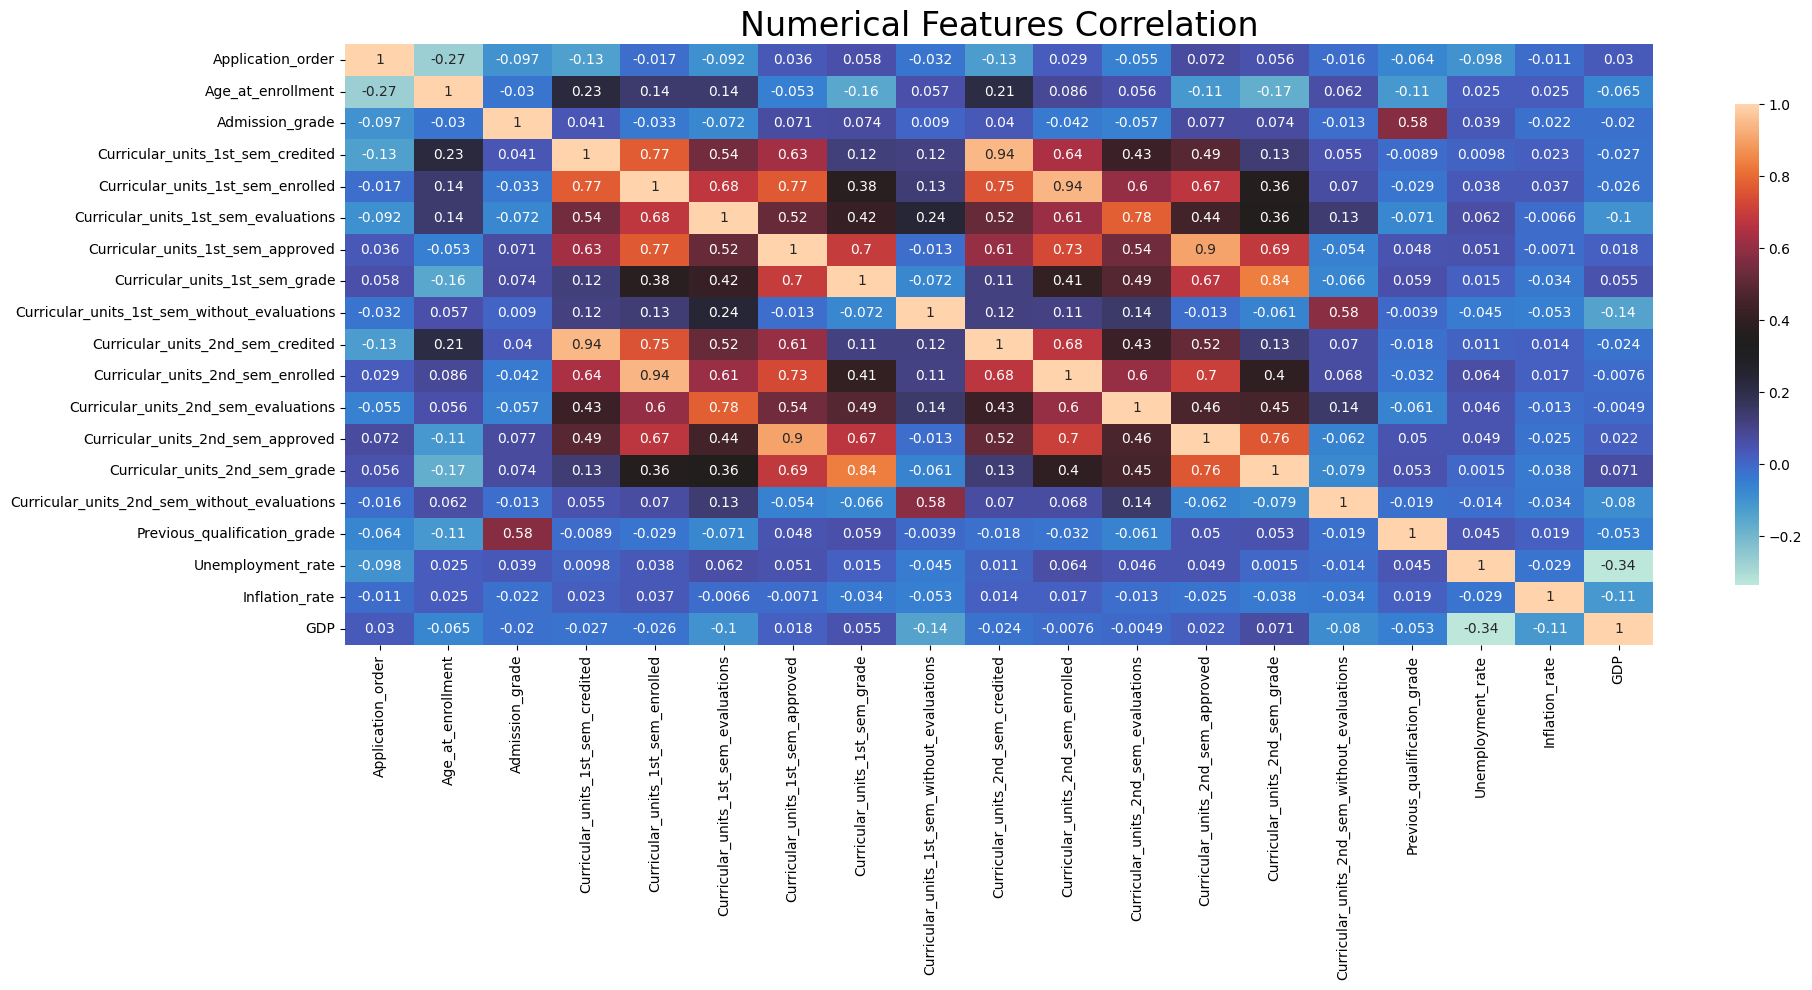

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(new_df[numerical_feat].corr(),
            annot=True,
            cmap='icefire',
            cbar_kws={'shrink': 0.8},
            annot_kws={"size": 10})
plt.title('Numerical Features Correlation', fontsize=24)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Berdasarkan heatmap korelasi fitur numerik, terlihat adanya hubungan yang cukup kuat antar beberapa variabel, khususnya antar variabel yang terkait dengan performa akademik mahasiswa. Misalnya, terdapat korelasi tinggi antara jumlah mata kuliah yang diambil, disetujui, dan nilai yang diperoleh, baik pada semester pertama maupun kedua. Ini mengindikasikan bahwa mahasiswa yang aktif mengikuti dan menyelesaikan mata kuliah cenderung memiliki hasil akademik yang lebih baik secara keseluruhan. Sementara itu, variabel ekonomi makro seperti tingkat pengangguran, inflasi, dan GDP memiliki korelasi yang sangat lemah terhadap variabel akademik, menunjukkan bahwa pengaruh faktor eksternal terhadap performa individu dalam konteks ini relatif kecil. Insight ini mendukung pentingnya pemantauan kinerja akademik internal sebagai indikator utama dalam analisis dropout.

In [ ]:
education_level_by_prev_qualification = {
    "Pendidikan Sekunder": "Pendidikan Menengah",
    "Pendidikan Tinggi - gelar sarjana": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar magister": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar doktor": "Pendidikan Tinggi",
    "Frekuensi pendidikan tinggi": "Lainnya",
    "Tahun ke-12 sekolah - tidak selesai": "Pendidikan Menengah",
    "Tahun ke-11 sekolah - tidak selesai": "Pendidikan Menengah",
    "Lainnya - Tahun ke-11 sekolah": "Pendidikan Menengah",
    "Tahun ke-10 sekolah": "Pendidikan Menengah",
    "Tahun ke-10 sekolah - tidak selesai": "Pendidikan Menengah",
    "Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara": "Pendidikan Dasar",
    "Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara": "Pendidikan Dasar",
    "Kursus Spesialisasi Teknologi": "Pendidikan Kursus dan Spesialisasi",
    "Pendidikan Tinggi - gelar (Siklus 1)": "Pendidikan Tinggi",
    "Kursus Teknis Tinggi Profesional": "Pendidikan Kursus dan Spesialisasi",
    "Pendidikan Tinggi - gelar magister (Siklus 2)": "Pendidikan Tinggi"
}

mother_education_levels = {
    "Pendidikan Sekunder - Tahun ke-12 sekolah atau Setara": "Pendidikan Menengah",
    "Pendidikan Tinggi - gelar sarjana": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar magister": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar doktor": "Pendidikan Tinggi",
    "Frekuensi Pendidikan Tinggi": "Pendidikan Tinggi",
    "Tahun ke-12 sekolah - Tidak Selesai": "Pendidikan Menengah",
    "Tahun ke-11 sekolah - Tidak Selesai": "Pendidikan Menengah",
    "Tahun ke-7 (Lama)": "Pendidikan Menengah",
    "Lainnya - Tahun ke-11 sekolah": "Pendidikan Menengah",
    "Tahun ke-10 sekolah": "Pendidikan Menengah",
    "Kursus Perdagangan Umum": "Pendidikan Kursus dan Spesialisasi",
    "Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara": "Pendidikan Dasar",
    "Kursus Teknis-Profesional": "Pendidikan Kursus dan Spesialisasi",
    "Tahun ke-7 sekolah": "Pendidikan Menengah",
    "Siklus 2 kursus SMA umum": "Pendidikan Menengah",
    "Tahun ke-9 sekolah - Tidak Selesai": "Pendidikan Menengah",
    "Tahun ke-8 sekolah": "Pendidikan Menengah",
    "Tidak diketahui": "Lainnya",
    "Tidak bisa membaca atau menulis": "Lainnya",
    "Bisa membaca tanpa memiliki tahun ke-4 sekolah": "Lainnya",
    "Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau setara": "Pendidikan Dasar",
    "Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara": "Pendidikan Dasar",
    "Kursus Spesialisasi Teknologi": "Pendidikan Kursus dan Spesialisasi",
    "Pendidikan Tinggi - gelar (Siklus 1)": "Pendidikan Tinggi",
    "Kursus Studi Tinggi Khusus": "Pendidikan Kursus dan Spesialisasi",
    "Kursus Teknis Tinggi Profesional": "Pendidikan Kursus dan Spesialisasi",
    "Pendidikan Tinggi - gelar magister (Siklus 2)": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar doktor (Siklus 3)": "Pendidikan Tinggi"
}

father_education_levels = {
    "Pendidikan Sekunder - Tahun ke-12 sekolah atau Setara": "Pendidikan Menengah",
    "Pendidikan Tinggi - gelar sarjana": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar magister": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar doktor": "Pendidikan Tinggi",
    "Frekuensi Pendidikan Tinggi": "Lainnya",
    "Tahun ke-12 sekolah - Tidak Selesai": "Pendidikan Menengah",
    "Tahun ke-11 sekolah - Tidak Selesai": "Pendidikan Menengah",
    "Tahun ke-7 (Lama)": "Pendidikan Menengah",
    "Lainnya - Tahun ke-11 sekolah": "Pendidikan Menengah",
    "Kursus SMA komplementer tahun ke-2": "Pendidikan Menengah",
    "Tahun ke-10 sekolah": "Pendidikan Menengah",
    "Kursus Perdagangan Umum": "Pendidikan Kursus dan Spesialisasi",
    "Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) atau setara": "Pendidikan Dasar",
    "Kursus SMA Komplementer": "Pendidikan Menengah",
    "Kursus Teknis-Profesional": "Pendidikan Kursus dan Spesialisasi",
    "Kursus SMA Komplementer - tidak selesai": "Pendidikan Menengah",
    "Tahun ke-7 sekolah": "Pendidikan Menengah",
    "Siklus 2 kursus SMA umum": "Pendidikan Menengah",
    "Tahun ke-9 sekolah - Tidak Selesai": "Pendidikan Menengah",
    "Tahun ke-8 sekolah": "Pendidikan Menengah",
    "Umum Administrasi dan Kursus Perdagangan": "Lainnya",
    "Akuntansi Tambahan dan Administrasi": "Lainnya",
    "Tidak diketahui": "Lainnya",
    "Tidak bisa membaca atau menulis": "Lainnya",
    "Bisa membaca tanpa memiliki tahun ke-4 sekolah": "Lainnya",
    "Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau setara": "Pendidikan Dasar",
    "Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) atau setara": "Pendidikan Dasar",
    "Kursus Spesialisasi Teknologi": "Pendidikan Kursus dan Spesialisasi",
    "Pendidikan Tinggi - gelar (Siklus 1)": "Pendidikan Tinggi",
    "Kursus Studi Tinggi Khusus": "Pendidikan Kursus dan Spesialisasi",
    "Kursus Teknis Tinggi Profesional": "Pendidikan Kursus dan Spesialisasi",
    "Pendidikan Tinggi - gelar magister (Siklus 2)": "Pendidikan Tinggi",
    "Pendidikan Tinggi - gelar doktor (Siklus 3)": "Pendidikan Tinggi"
}

new_df["Previous_edu_level"] = new_df["Previous_qualification"].map(education_level_by_prev_qualification)
new_df["Mother_edu_level"] = new_df["Mothers_qualification"].map(mother_education_levels)
new_df["Father_edu_level"] = new_df["Fathers_qualification"].map(father_education_levels)

print(new_df["Previous_edu_level"].unique())
print(new_df["Mother_edu_level"].unique())
print(new_df["Father_edu_level"].unique())

['Pendidikan Menengah' 'Pendidikan Dasar'
 'Pendidikan Kursus dan Spesialisasi' 'Pendidikan Tinggi' 'Lainnya']
['Pendidikan Dasar' 'Pendidikan Menengah' 'Pendidikan Tinggi'
 'Pendidikan Kursus dan Spesialisasi' 'Lainnya']
['Pendidikan Menengah' 'Pendidikan Tinggi' 'Pendidikan Dasar' 'Lainnya'
 'Pendidikan Kursus dan Spesialisasi']


In [ ]:
mother_occupation_classified = {
        "Spesialis dalam Aktivitas Intelektual dan Ilmiah": "Profesi Akademik dan Spesialis",
        "Teknisi dan Profesi Tingkat Menengah": "Profesi Akademik dan Spesialis",
        "Profesional Kesehatan": "Profesi Akademik dan Spesialis",
        "Guru": "Profesi Akademik dan Spesialis",
        "Spesialis dalam teknologi informasi dan komunikasi (TIK)": "Profesi Akademik dan Spesialis",
        "Teknisi dan Profesi Tingkat Menengah dalam Ilmu Pengetahuan dan Teknik": "Profesi Akademik dan Spesialis",
        "Teknisi dan Profesional, tingkat menengah dari kesehatan": "Profesi Akademik dan Spesialis",
        "Teknisi tingkat menengah dari layanan hukum, sosial, olahraga, budaya, dan sejenisnya": "Profesi Akademik dan Spesialis",
        "Tenaga Kerja Terampil di Industri, Konstruksi, dan Pengrajin": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Operator Pemasangan dan Mesin serta Pekerja Perakitan": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga Kerja Terampil": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja terampil dalam konstruksi dan sejenisnya, kecuali tukang listrik": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja terampil dalam percetakan, pembuatan instrumen presisi, perhiasan, pengrajin, dan sejenisnya": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja di bidang pengolahan makanan, kayu, pakaian, dan industri serta kerajinan lainnya": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja tidak terampil di industri ekstraktif, konstruksi, manufaktur, dan transportasi": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Staf Administrasi": "Bidang Layanan Publik dan Komersial",
        "Pelayanan Personal, Pekerja Keamanan dan Keselamatan, serta Penjual": "Bidang Layanan Publik dan Komersial",
        "Pekerja kantor, sekretaris umum, dan operator pengolahan data": "Bidang Layanan Publik dan Komersial",
        "Operator data, akuntansi, statistik, layanan keuangan, dan yang terkait dengan registrasi" : "Bidang Layanan Publik dan Komersial",
        "Staf dukungan administratif lainnya": "Bidang Layanan Publik dan Komersial",
        "Pekerja layanan personal": "Bidang Layanan Publik dan Komersial",
        "Penjual": "Bidang Layanan Publik dan Komersial",
        "Pekerja perawatan pribadi dan sejenisnya": "Bidang Layanan Publik dan Komersial",
        "Pekerja pembersihan": "Bidang Layanan Publik dan Komersial",
        "Asisten persiapan makanan": "Bidang Layanan Publik dan Komersial",
        "Petani dan Tenaga Kerja Terampil di Pertanian, Perikanan, dan Kehutanan": "Bidang Pertanian, Perikanan, dan Kehutanan",
        "Tenaga kerja tidak terampil di pertanian, produksi hewan, perikanan, dan kehutanan": "Bidang Pertanian, Perikanan, dan Kehutanan",
        "Profesi Angkatan Bersenjata": "Profesi Militer dan Angkatan Bersenjata",
        "Siswa": "Bidang Lainnya",
        "Situasi Lainnya": "Bidang Lainnya",
        "(kosong)": "Bidang Lainnya",
        "Wakil Kekuasaan Legislatif dan Badan Eksekutif, Direktur, Manajer Eksekutif dan Direktur": "Bidang Lainnya"
}

father_occupation_classified = {
        "Spesialis dalam Aktivitas Intelektual dan Ilmiah": "Profesi Akademik dan Spesialis",
        "Teknisi dan Profesi Tingkat Menengah": "Profesi Akademik dan Spesialis",
        "Spesialis dalam ilmu fisika, matematika, teknik, dan teknik terkait": "Profesi Akademik dan Spesialis",
        "Profesional Kesehatan": "Profesi Akademik dan Spesialis",
        "Guru": "Profesi Akademik dan Spesialis",
        "Spesialis dalam keuangan, akuntansi, organisasi administratif, hubungan publik, dan komersial": "Profesi Akademik dan Spesialis",
        "Teknisi dan Profesi Tingkat Menengah dalam Ilmu Pengetahuan dan Teknik": "Profesi Akademik dan Spesialis",
        "Teknisi dan Profesional, tingkat menengah dari kesehatan": "Profesi Akademik dan Spesialis",
        "Teknisi tingkat menengah dari layanan hukum, sosial, olahraga, budaya, dan sejenisnya": "Profesi Akademik dan Spesialis",
        "Teknisi Teknologi Informasi dan Komunikasi": "Profesi Akademik dan Spesialis",
        "Tenaga Kerja Terampil di Industri, Konstruksi, dan Pengrajin": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Operator Pemasangan dan Mesin serta Pekerja Perakitan": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga Kerja Terampil": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Operator pabrik dan mesin tetap": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Pekerja perakitan": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Pengemudi kendaraan dan operator peralatan mobile": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja tidak terampil di industri ekstraktif, konstruksi, manufaktur, dan transportasi": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja terampil dalam konstruksi dan sejenisnya, kecuali tukang listrik": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja terampil dalam logamurgi, permesinan logam, dan sejenisnya": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja terampil dalam listrik dan elektronika": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Tenaga kerja di bidang pengolahan makanan, kayu, pakaian, dan industri serta kerajinan lainnya": "Bidang Industri, Konstruksi, dan Kerajinan",
        "Staf Administrasi": "Bidang Layanan Publik dan Komersial",
        "Pelayanan Personal, Pekerja Keamanan dan Keselamatan, serta Penjual": "Bidang Layanan Publik dan Komersial",
        "Direktur Layanan Administratif dan Komersial": "Bidang Layanan Publik dan Komersial",
        "Direktur Hotel, Restoran, Perdagangan, dan Layanan Lainnya": "Bidang Layanan Publik dan Komersial",
        "Pekerja kantor, sekretaris umum, dan operator pengolahan data": "Bidang Layanan Publik dan Komersial",
        "Operator data, akuntansi, statistik, layanan keuangan, dan yang terkait dengan registrasi": "Bidang Layanan Publik dan Komersial",
        "Staf dukungan administratif lainnya": "Bidang Layanan Publik dan Komersial",
        "Pekerja layanan personal": "Bidang Layanan Publik dan Komersial",
        "Penjual": "Bidang Layanan Publik dan Komersial",
        "Pekerja perawatan pribadi dan sejenisnya": "Bidang Layanan Publik dan Komersial",
        "Personil layanan perlindungan dan keamanan": "Bidang Layanan Publik dan Komersial",
        "Umum Administrasi dan Kursus Perdagangan": "Bidang Layanan Publik dan Komersial",
        "Akuntansi Tambahan dan Administrasi": "Bidang Layanan Publik dan Komersial",
        "Asisten persiapan makanan": "Bidang Layanan Publik dan Komersial",
        "Pedagang jalanan (kecuali makanan) dan penyedia layanan jalanan": "Bidang Layanan Publik dan Komersial",
        "Petani dan Tenaga Kerja Terampil di Pertanian, Perikanan, dan Kehutanan": "Bidang Pertanian, Perikanan, dan Kehutanan",
        "Petani berorientasi pasar dan tenaga kerja pertanian terampil dan produksi hewan": "Bidang Pertanian, Perikanan, dan Kehutanan",
        "Petani, pemelihara hewan, nelayan, pemburu, dan pengumpul, untuk pemenuhan kebutuhan": "Bidang Pertanian, Perikanan, dan Kehutanan",
        "Tenaga kerja tidak terampil di pertanian, produksi hewan, perikanan, dan kehutanan": "Bidang Pertanian, Perikanan, dan Kehutanan",
        "Profesi Angkatan Bersenjata": "Profesi Militer dan Angkatan Bersenjata",
        "Perwira Angkatan Bersenjata": "Profesi Militer dan Angkatan Bersenjata",
        "Sersan Angkatan Bersenjata": "Profesi Militer dan Angkatan Bersenjata",
        "Personel Angkatan Bersenjata Lainnya": "Profesi Militer dan Angkatan Bersenjata",
        "Siswa": "Bidang Lainnya",
        "Situasi Lainnya": "Bidang Lainnya",
        "(kosong)": "Bidang Lainnya",
        "Wakil Kekuasaan Legislatif dan Badan Eksekutif, Direktur, Manajer Eksekutif dan Direktur": "Bidang Lainnya"
}

new_df["Mother_field_of_work"] = new_df["Mothers_occupation"].map(mother_occupation_classified)
new_df["Father_field_of_work"] = new_df["Fathers_occupation"].map(father_occupation_classified)

print(sorted(new_df["Mother_field_of_work"].unique()))
print(sorted(new_df["Father_field_of_work"].unique()))

['Bidang Industri, Konstruksi, dan Kerajinan', 'Bidang Lainnya', 'Bidang Layanan Publik dan Komersial', 'Bidang Pertanian, Perikanan, dan Kehutanan', 'Profesi Akademik dan Spesialis', 'Profesi Militer dan Angkatan Bersenjata']
['Bidang Industri, Konstruksi, dan Kerajinan', 'Bidang Lainnya', 'Bidang Layanan Publik dan Komersial', 'Bidang Pertanian, Perikanan, dan Kehutanan', 'Profesi Akademik dan Spesialis', 'Profesi Militer dan Angkatan Bersenjata']


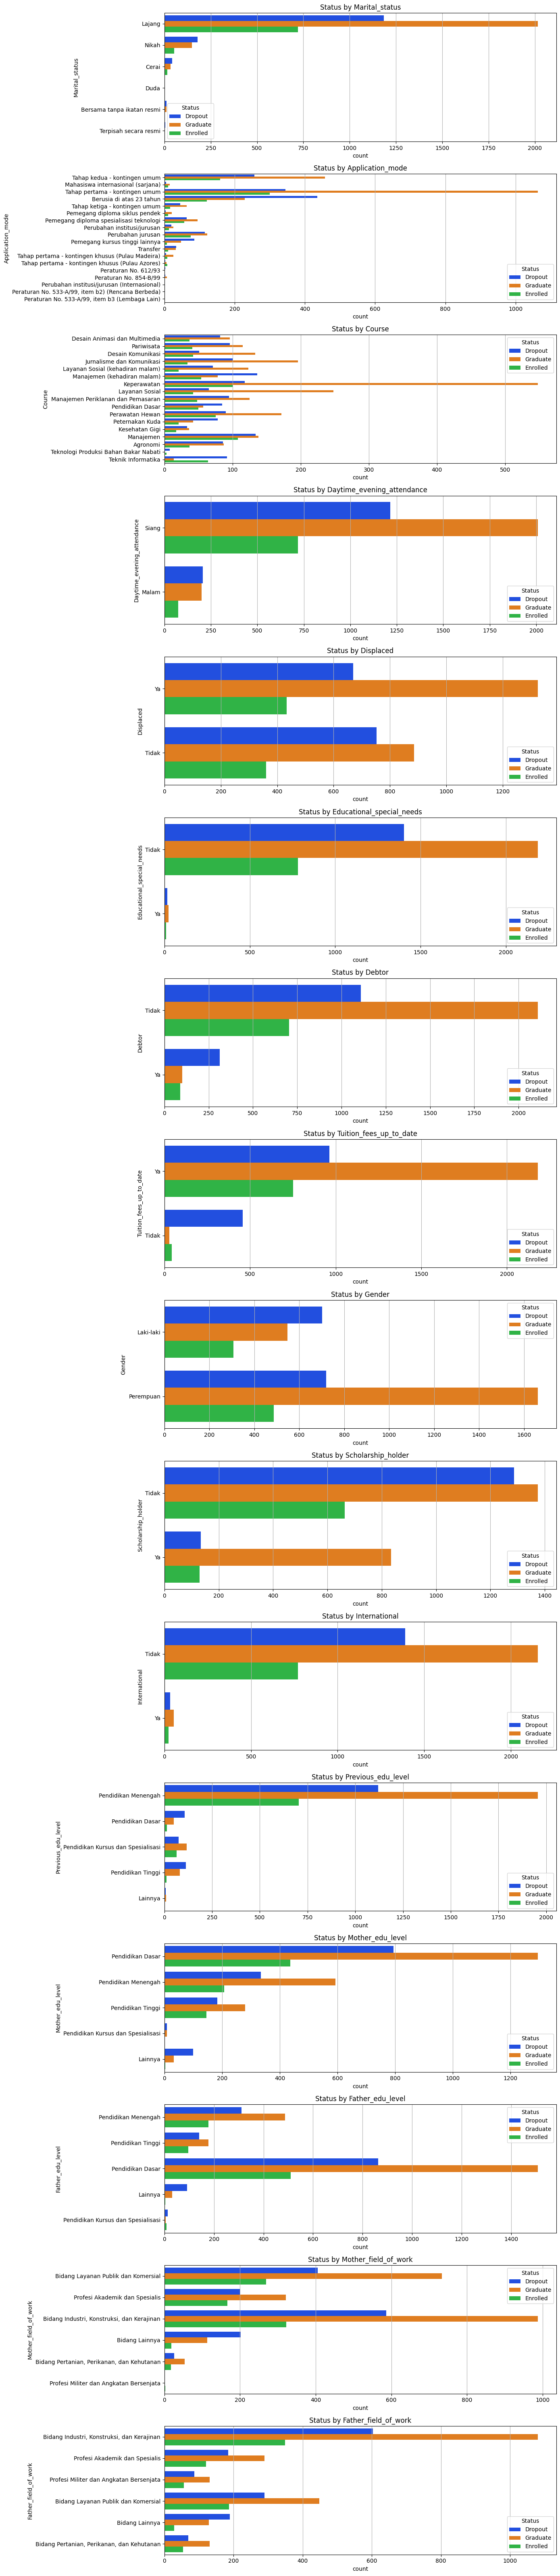

In [ ]:
categorical_feat.remove("Previous_qualification")
categorical_feat.remove("Mothers_qualification")
categorical_feat.remove("Fathers_qualification")
categorical_feat.remove("Mothers_occupation")
categorical_feat.remove("Fathers_occupation")
categorical_feat.remove("Nacionality")
categorical_feat.append("Previous_edu_level")
categorical_feat.append("Mother_edu_level")
categorical_feat.append("Father_edu_level")
categorical_feat.append("Mother_field_of_work")
categorical_feat.append("Father_field_of_work")

cat_plot(new_df, categorical_feat, segment_by="Status")

Berdasarkan visualisasi tersebut, terdapat beberapa pola menarik yang memengaruhi kemungkinan siswa untuk dropout. Siswa yang sudah menikah cenderung lebih sering mengalami dropout dibandingkan yang masih lajang. Selain itu, siswa yang masuk perguruan tinggi melalui jalur berusia di atas 23 tahun dan pemegang kursus tinggi lainnya menunjukkan angka dropout yang lebih tinggi, kemungkinan karena berkurangnya motivasi belajar seiring bertambahnya usia dan lebih fokus pada karier. Kursus seperti manajemen, pendidikan dasar, peternakan kuda, dan teknik informatika juga tercatat memiliki tingkat dropout yang lebih tinggi, sedangkan kursus teknologi produksi bahan bakar nabati memiliki jumlah siswa yang sangat sedikit dengan hampir tidak ada siswa yang lulus. Rasio kelulusan siswa di kelas siang lebih tinggi dibandingkan kelas malam. Siswa yang memiliki pinjaman atau utang serta yang biaya pendidikannya belum terbayar cenderung lebih rentan mengalami dropout. Selain itu, siswa laki-laki menunjukkan angka dropout yang lebih tinggi dibandingkan siswa perempuan, sementara siswa dengan beasiswa memiliki tingkat kelulusan yang lebih tinggi dibandingkan mereka yang tidak mendapat beasiswa.

In [ ]:
## DOWNLOAD DATASET UNTUK DASHBOARD ##
# new_df.insert(1, "Student", range(1, len(new_df) + 1))
# new_df.to_csv("cleaned_data_student.csv", index=False)
# new_df.head()

,Marital_status,Student,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,...,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Previous_edu_level,Mother_edu_level,Father_edu_level,Mother_field_of_work,Father_field_of_work
0,Lajang,1,Tahap kedua - kontingen umum,5,Desain Animasi dan Multimedia,Siang,Pendidikan Sekunder,122.0,Portugis,Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) a...,...,0,10.8,1.4,1.74,Dropout,Pendidikan Menengah,Pendidikan Dasar,Pendidikan Menengah,Bidang Layanan Publik dan Komersial,"Bidang Industri, Konstruksi, dan Kerajinan"
1,Lajang,2,Mahasiswa internasional (sarjana),1,Pariwisata,Siang,Pendidikan Sekunder,160.0,Portugis,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,...,0,13.9,-0.3,0.79,Graduate,Pendidikan Menengah,Pendidikan Menengah,Pendidikan Tinggi,Profesi Akademik dan Spesialis,Profesi Akademik dan Spesialis
2,Lajang,3,Tahap pertama - kontingen umum,5,Desain Komunikasi,Siang,Pendidikan Sekunder,122.0,Portugis,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,0,10.8,1.4,1.74,Dropout,Pendidikan Menengah,Pendidikan Dasar,Pendidikan Dasar,"Bidang Industri, Konstruksi, dan Kerajinan","Bidang Industri, Konstruksi, dan Kerajinan"
3,Lajang,4,Tahap kedua - kontingen umum,2,Jurnalisme dan Komunikasi,Siang,Pendidikan Sekunder,122.0,Portugis,Pendidikan Dasar Siklus 2 (Tahun ke-6/7/8) ata...,...,0,9.4,-0.8,-3.12,Graduate,Pendidikan Menengah,Pendidikan Dasar,Pendidikan Dasar,Bidang Layanan Publik dan Komersial,Profesi Akademik dan Spesialis
4,Nikah,5,Berusia di atas 23 tahun,1,Layanan Sosial (kehadiran malam),Malam,Pendidikan Sekunder,100.0,Portugis,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,0,13.9,-0.3,0.79,Graduate,Pendidikan Menengah,Pendidikan Dasar,Pendidikan Dasar,"Bidang Industri, Konstruksi, dan Kerajinan","Bidang Industri, Konstruksi, dan Kerajinan"


## Data Preparation / Preprocessing

In [ ]:
new_df.Status.value_counts()

,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


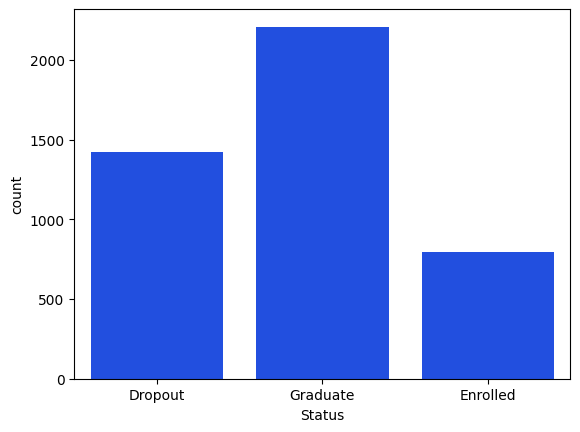

In [ ]:
sns.countplot(data=new_df, x="Status")
plt.show()

In [ ]:
import os

folder_name = "data_folder"

try:
    os.mkdir(folder_name)
except FileExistsError:
    print(f"The folder '{folder_name}' already exists.")

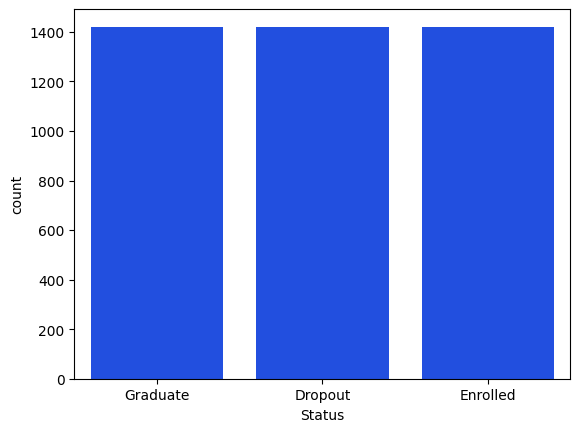

In [ ]:
from sklearn.utils import resample, shuffle

dropout_df = new_df[new_df["Status"] == "Dropout"].copy()
enrolled_df = new_df[new_df["Status"] == "Enrolled"].copy()
graduate_df = new_df[new_df["Status"] == "Graduate"].copy()

# Undersampling
graduate_undersampled_df = resample(graduate_df, n_samples=len(dropout_df), random_state=123)

# Oversampling
enrolled_oversampled_df = resample(enrolled_df, n_samples=len(dropout_df), random_state=123)

concated_df = pd.concat([graduate_undersampled_df,
                         dropout_df,
                         enrolled_oversampled_df]).reset_index(drop=True)

concated_df = shuffle(concated_df, random_state=123)
concated_df.reset_index(drop=True, inplace=True)
sns.countplot(data=concated_df, x="Status")
plt.show()

In [ ]:
import numpy as np
id_values = np.array(range(len(concated_df)))

main_df = concated_df.copy()
main_df["StudentID"] = id_values.astype(int)
main_df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Unemployment_rate,Inflation_rate,GDP,Status,Previous_edu_level,Mother_edu_level,Father_edu_level,Mother_field_of_work,Father_field_of_work,StudentID
0,Lajang,Tahap pertama - kontingen umum,2,Keperawatan,Siang,Pendidikan Sekunder,112.0,Portugis,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,12.4,0.5,1.79,Graduate,Pendidikan Menengah,Pendidikan Menengah,Pendidikan Dasar,Bidang Layanan Publik dan Komersial,"Bidang Industri, Konstruksi, dan Kerajinan",0
1,Lajang,Tahap pertama - kontingen umum,1,Teknik Informatika,Siang,Pendidikan Sekunder,129.0,Portugis,Lainnya - Tahun ke-11 sekolah,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,...,7.6,2.6,0.32,Dropout,Pendidikan Menengah,Pendidikan Menengah,Pendidikan Menengah,Bidang Layanan Publik dan Komersial,Profesi Militer dan Angkatan Bersenjata,1
2,Lajang,Perubahan jurusan,1,Manajemen,Siang,Pendidikan Sekunder,123.0,Portugis,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,Pendidikan Sekunder - Tahun ke-12 sekolah atau...,...,15.5,2.8,-4.06,Dropout,Pendidikan Menengah,Pendidikan Menengah,Pendidikan Menengah,Bidang Layanan Publik dan Komersial,Bidang Layanan Publik dan Komersial,2
3,Lajang,Perubahan jurusan,1,Manajemen Periklanan dan Pemasaran,Siang,Pendidikan Sekunder,132.0,Portugis,Pendidikan Tinggi - gelar,Pendidikan Dasar Siklus 3 (Tahun ke-9/10/11) a...,...,13.9,-0.3,0.79,Enrolled,Pendidikan Menengah,Pendidikan Tinggi,Pendidikan Dasar,Bidang Layanan Publik dan Komersial,"Bidang Industri, Konstruksi, dan Kerajinan",3
4,Lajang,Berusia di atas 23 tahun,1,Keperawatan,Siang,Pendidikan Sekunder,120.0,Portugis,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,Pendidikan Dasar Siklus 1 (Tahun ke-4/5) atau ...,...,16.2,0.3,-0.92,Enrolled,Pendidikan Menengah,Pendidikan Dasar,Pendidikan Dasar,"Bidang Industri, Konstruksi, dan Kerajinan","Bidang Industri, Konstruksi, dan Kerajinan",4


In [ ]:
num_list = numerical_feat.copy()
num_list.append("StudentID")

numerical_df = main_df[num_list].copy()
numerical_df.drop(["Application_order",
                   "Curricular_units_1st_sem_credited",
                   "Curricular_units_1st_sem_without_evaluations",
                   "Curricular_units_2nd_sem_credited",
                   "Curricular_units_2nd_sem_without_evaluations",
                   "Previous_qualification_grade",
                   "Inflation_rate",
                   "Unemployment_rate",
                   "GDP"], axis=1, inplace=True)
numerical_df.head()

,Age_at_enrollment,Admission_grade,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,StudentID
0,19,106.8,7,8,6,13.533333,8,9,7,13.614286,0
1,19,124.1,5,10,0,0.000000,5,10,1,14.000000,1
2,22,114.4,5,6,0,0.000000,5,8,2,11.500000,2
3,19,120.5,6,17,4,12.500000,6,8,4,13.250000,3
4,34,100.0,7,15,6,11.333333,7,16,4,12.600000,4


In [ ]:
cat_list = categorical_feat.copy()
cat_list.append("StudentID")

categorical_df = main_df[cat_list].copy()
categorical_df.drop(["Marital_status",
                     "Application_mode",
                     "Course",
                     "Educational_special_needs",
                     "International",
                     "Previous_edu_level",
                     "Mother_edu_level",
                     "Father_edu_level",
                     "Mother_field_of_work",
                     "Father_field_of_work"], axis=1, inplace=True)

categorical_df.head()

,Daytime_evening_attendance,Displaced,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,StudentID
0,Siang,Ya,Tidak,Ya,Perempuan,Ya,0
1,Siang,Ya,Tidak,Ya,Laki-laki,Tidak,1
2,Siang,Tidak,Tidak,Ya,Laki-laki,Tidak,2
3,Siang,Tidak,Tidak,Ya,Laki-laki,Tidak,3
4,Siang,Tidak,Tidak,Ya,Laki-laki,Tidak,4


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer
import joblib

In [ ]:
pca_columns_1 = [
    "Curricular_units_1st_sem_enrolled",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_enrolled",
    "Curricular_units_2nd_sem_approved",
    "Curricular_units_2nd_sem_grade"
]

pca_columns_2 = ["Curricular_units_1st_sem_evaluations","Curricular_units_2nd_sem_evaluations"]

In [ ]:
pca1 = PCA(n_components=len(pca_columns_1), random_state=42)
pca1.fit(numerical_df[pca_columns_1])
pca1.explained_variance_ratio_.round(4)

array([0.7711, 0.128 , 0.0618, 0.0264, 0.01  , 0.0027])

In [ ]:
pca1 = PCA(n_components=2, random_state=42)
pca1.fit(numerical_df[pca_columns_1])
numerical_df[["pca1_1","pca1_2"]] = pca1.transform(numerical_df[pca_columns_1])
numerical_df.drop(pca_columns_1, axis=1, inplace=True)
joblib.dump(pca1, "data_folder/enroll_approve_grade_1st_2nd")
numerical_df.head()

,Age_at_enrollment,Admission_grade,Curricular_units_1st_sem_evaluations,Curricular_units_2nd_sem_evaluations,StudentID,pca1_1,pca1_2
0,19,106.8,8,9,0,6.101793,0.780672
1,19,124.1,10,10,1,-6.165937,-2.251429
2,22,114.4,6,8,2,-7.441624,-1.079950
3,19,120.5,17,8,3,3.213084,-2.042569
4,34,100.0,15,16,4,3.067882,0.351781


In [ ]:
pca2 = PCA(n_components=len(pca_columns_2), random_state=42)
pca2.fit(numerical_df[pca_columns_2])
pca2.explained_variance_ratio_.round(4)

array([0.8797, 0.1203])

In [ ]:
pca2 = PCA(n_components=1, random_state=75)
pca2.fit(numerical_df[pca_columns_2])
numerical_df["pca2"] = pca2.transform(numerical_df[pca_columns_2])
numerical_df.drop(pca_columns_2, axis=1, inplace=True)
joblib.dump(pca2, "data_folder/eval_1st_2nd")
numerical_df.head()

,Age_at_enrollment,Admission_grade,StudentID,pca1_1,pca1_2,pca2
0,19,106.8,0,6.101793,0.780672,0.261519
1,19,124.1,1,-6.165937,-2.251429,2.392371
2,22,114.4,2,-7.441624,-1.079950,-1.869333
3,19,120.5,3,3.213084,-2.042569,6.015165
4,34,100.0,4,3.067882,0.351781,10.160076


In [ ]:
def power_transformers(df, features):
    transformed_features_list = []
    transformed_df = df.copy()
    for feature in features:
        transformer = PowerTransformer()
        y = np.array(transformed_df[feature])
        y = y.reshape(-1,1)
        transformer.fit(y)
        transformed_df[f"Transformed_{feature}"] = np.round(transformer.transform(y), 3)
        transformed_df.drop(feature, axis=1, inplace=True)
        joblib.dump(transformer, f"data_folder/Transformed_{feature}")
        transformed_features_list.append(f"Transformed_{feature}")
    return transformed_df, transformed_features_list

In [ ]:
features_to_transformed = [
    "Admission_grade",
    "Age_at_enrollment",
    "pca1_1",
    "pca1_2",
    "pca2"]

numerical_preprocessed_df, list_ = power_transformers(numerical_df, features_to_transformed)
numerical_preprocessed_df

,StudentID,Transformed_Admission_grade,Transformed_Age_at_enrollment,Transformed_pca1_1,Transformed_pca1_2,Transformed_pca2
0,0,-1.443,-0.683,0.965,0.543,0.063
1,1,-0.082,-0.683,-1.016,-0.819,0.452
2,2,-0.811,0.319,-1.101,-0.180,-0.334
3,3,-0.343,-0.683,0.186,-0.697,1.105
4,4,-2.062,1.568,0.151,0.411,1.845
...,...,...,...,...,...,...
4258,4258,-0.763,-0.278,-1.540,1.139,-2.222
4259,4259,0.059,-1.189,-0.983,-0.168,-0.338
4260,4260,-0.269,0.050,0.363,-0.606,-0.327
4261,4261,1.699,0.319,0.630,-1.238,-0.200


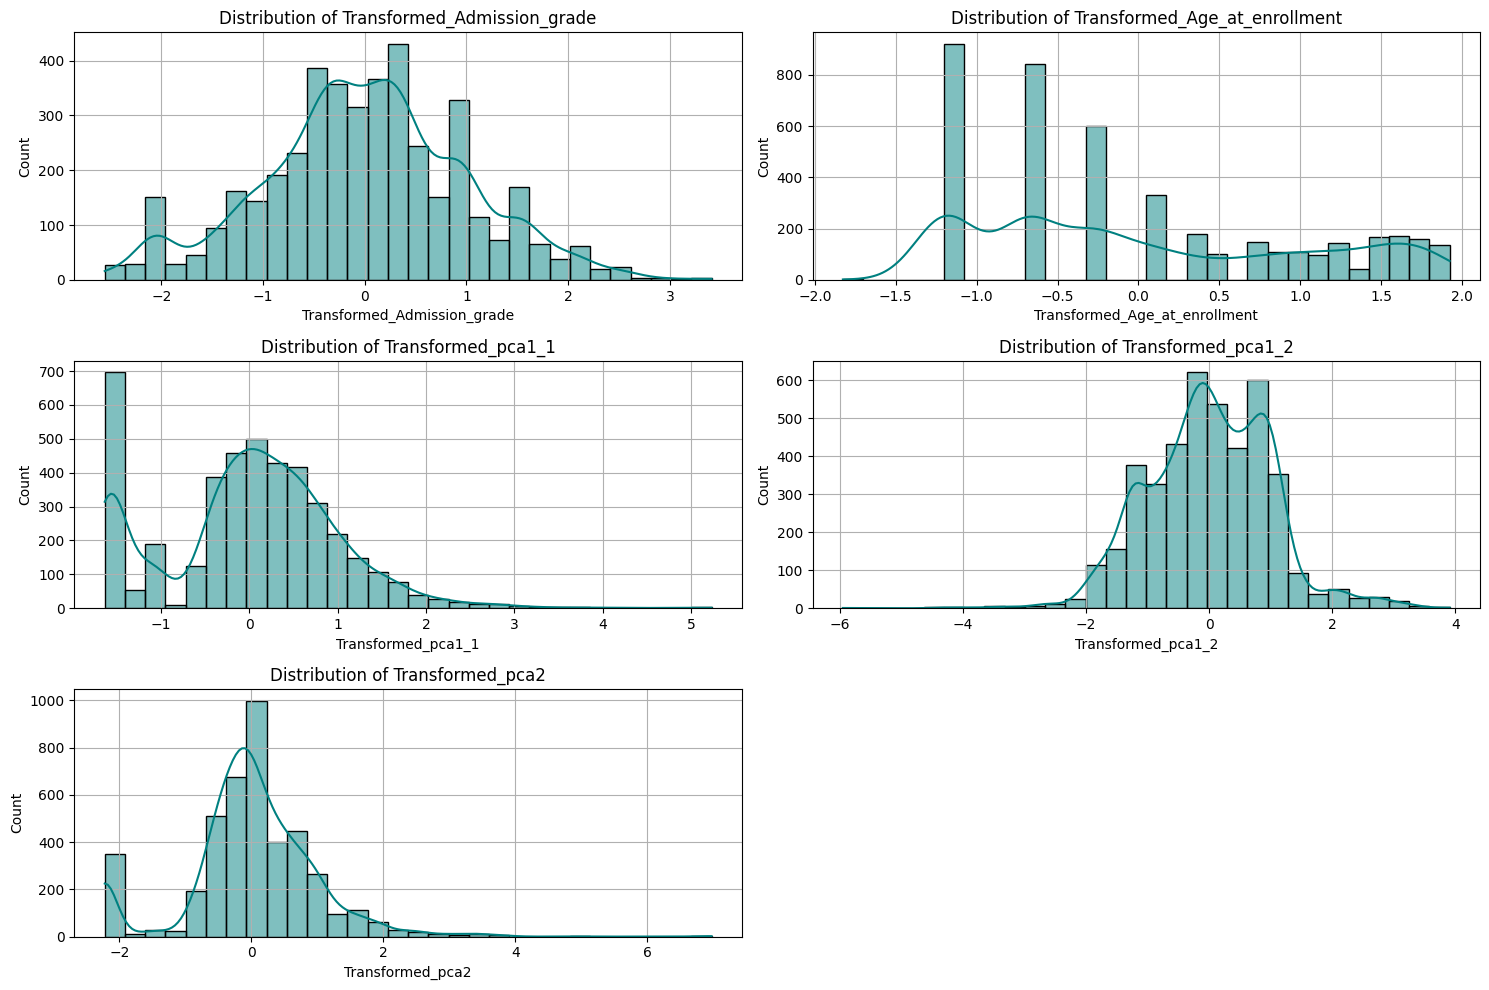

In [ ]:
transformed_columns = [
    "Transformed_Admission_grade",
    "Transformed_Age_at_enrollment",
    "Transformed_pca1_1",
    "Transformed_pca1_2",
    "Transformed_pca2"
]


plt.figure(figsize=(15, 10))
for i, col in enumerate(transformed_columns):
    plt.subplot(3, 2, i+1)
    sns.histplot(numerical_preprocessed_df[col], kde=True, bins=30, color="teal")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

Gambar menunjukkan distribusi empat variabel transformasi: Transformed_Admission_grade simetris di sekitar 0, Transformed_pca1_1 miring ke kanan, Transformed_pca2 normal dengan puncak tajam di 0, dan Transformed_pca1_2 bimodal (-4 dan 2). Transformasi ini menandai normalisasi data dan reduksi dimensi untuk analisis lebih lanjut.

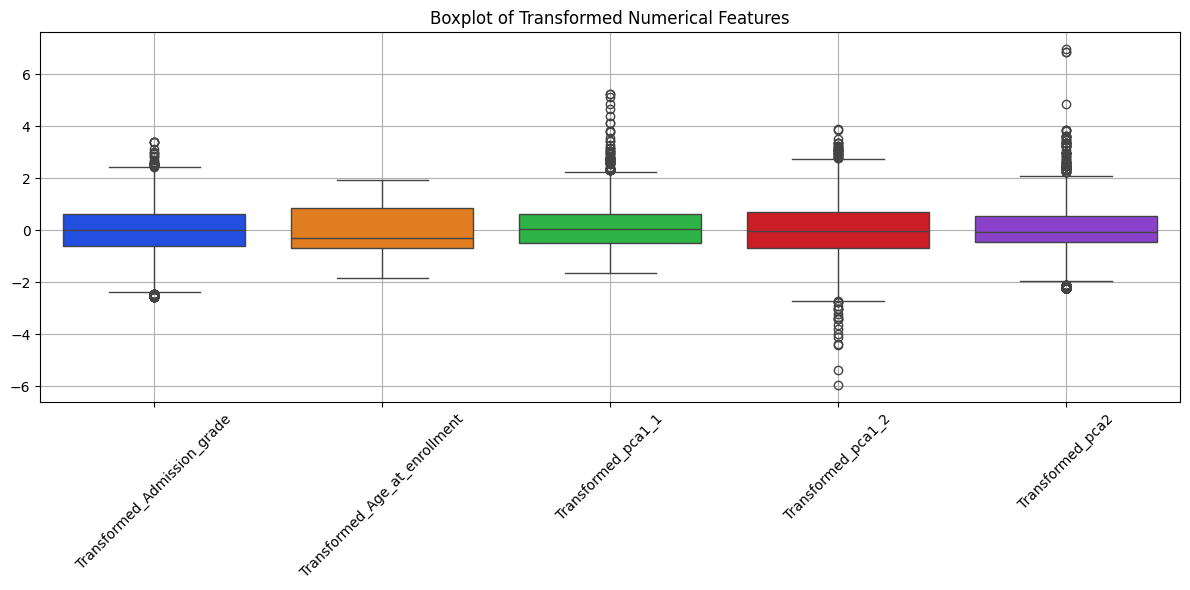

In [ ]:
transformed_cols = [
    "Transformed_Admission_grade",
    "Transformed_Age_at_enrollment",
    "Transformed_pca1_1",
    "Transformed_pca1_2",
    "Transformed_pca2"
]

plt.figure(figsize=(12, 6))
sns.boxplot(data=numerical_preprocessed_df[transformed_cols])
plt.title("Boxplot of Transformed Numerical Features")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
cat_dummies_df = pd.get_dummies(categorical_df, dtype="int")
cat_dummies_df.head()

,StudentID,Daytime_evening_attendance_Malam,Daytime_evening_attendance_Siang,Displaced_Tidak,Displaced_Ya,Debtor_Tidak,Debtor_Ya,Tuition_fees_up_to_date_Tidak,Tuition_fees_up_to_date_Ya,Gender_Laki-laki,Gender_Perempuan,Scholarship_holder_Tidak,Scholarship_holder_Ya
0,0,0,1,0,1,1,0,0,1,0,1,0,1
1,1,0,1,0,1,1,0,0,1,1,0,1,0
2,2,0,1,1,0,1,0,0,1,1,0,1,0
3,3,0,1,1,0,1,0,0,1,1,0,1,0
4,4,0,1,1,0,1,0,0,1,1,0,1,0


In [ ]:
merged_1_df = pd.merge(main_df[["StudentID","Status"]], numerical_preprocessed_df, on="StudentID")
merged_2_df = pd.merge(merged_1_df, cat_dummies_df, on="StudentID")
final_data = merged_2_df.copy()
final_data.drop("StudentID", axis=1, inplace=True)
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4263 entries, 0 to 4262
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Status                            4263 non-null   object 
 1   Transformed_Admission_grade       4263 non-null   float64
 2   Transformed_Age_at_enrollment     4263 non-null   float64
 3   Transformed_pca1_1                4263 non-null   float64
 4   Transformed_pca1_2                4263 non-null   float64
 5   Transformed_pca2                  4263 non-null   float64
 6   Daytime_evening_attendance_Malam  4263 non-null   int64  
 7   Daytime_evening_attendance_Siang  4263 non-null   int64  
 8   Displaced_Tidak                   4263 non-null   int64  
 9   Displaced_Ya                      4263 non-null   int64  
 10  Debtor_Tidak                      4263 non-null   int64  
 11  Debtor_Ya                         4263 non-null   int64  
 12  Tuitio

## Modeling

In [ ]:
from sklearn.model_selection import train_test_split

X = final_data.drop("Status", axis=1)
y = final_data["Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
X_train.shape, X_test.shape

((3197, 17), (1066, 17))

In [ ]:
y_train.value_counts(), y_test.value_counts()

(Status
 Enrolled    1066
 Dropout     1066
 Graduate    1065
 Name: count, dtype: int64,
 Status
 Graduate    356
 Enrolled    355
 Dropout     355
 Name: count, dtype: int64)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_model = DecisionTreeClassifier(random_state=123)

param_grid = {
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [10, 20, 30, 40],
    'criterion' :['gini', 'entropy']
}

CV_tree = GridSearchCV(estimator=tree_model, param_grid=param_grid, cv=5, n_jobs=-1)
CV_tree.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=123),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30, 40],
                         'max_features': ['auto', 'sqrt', 'log2']})

In [ ]:
print("best parameters: ", CV_tree.best_params_)

best parameters:  {'criterion': 'entropy', 'max_depth': 30, 'max_features': 'sqrt'}


In [ ]:
tree_model = DecisionTreeClassifier(
    random_state=123,
    criterion='entropy',
    max_depth=30,
    max_features='sqrt'
)

tree_model.fit(X_train, y_train)
joblib.dump(tree_model, "data_folder/tree_model.joblib")

['data_folder/tree_model.joblib']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RFmodel = RandomForestClassifier(random_state=123)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [10, 20, 30],
    'criterion' :['gini', 'entropy']
}

CV_RFmodel = GridSearchCV(estimator=RFmodel, param_grid=param_grid, cv=5, n_jobs=-1)
CV_RFmodel.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
90 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=123),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 300, 500]})

In [ ]:
print("best parameters: ", CV_RFmodel.best_params_)

best parameters:  {'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}


In [ ]:
RFmodel = RandomForestClassifier(
    random_state=123,
    max_depth=20,
    n_estimators=200,
    max_features='sqrt',
    criterion='entropy',
    n_jobs=-1
)
RFmodel.fit(X_train, y_train)
joblib.dump(RFmodel, "data_folder/rf_model.joblib")

['data_folder/rf_model.joblib']

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gboost_model = GradientBoostingClassifier(random_state=123)

param_grid = {
    'max_depth': [15, 20],
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_features': ['auto', 'sqrt', 'log2']
}

CV_gboost = GridSearchCV(estimator=gboost_model, param_grid=param_grid, cv=5, n_jobs=-1)
CV_gboost.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", l

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=123),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [15, 20],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 300]})

In [ ]:
print("best parameters: ", CV_gboost.best_params_)

best parameters:  {'learning_rate': 0.1, 'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 200}


In [ ]:
gboost_model = GradientBoostingClassifier(
    random_state=123,
    learning_rate=0.05,
    max_depth=15,
    max_features='sqrt',
    n_estimators=300,
    n_iter_no_change=20,
    validation_fraction=0.1
)
gboost_model.fit(X_train, y_train)
joblib.dump(gboost_model, "data_folder/gboost_model.joblib")

['data_folder/gboost_model.joblib']

## Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluating(y_pred, y_true):
    '''Evaluasi model'''
    labels = ['Graduate', 'Dropout', 'Enrolled']

    print(classification_report(y_true=y_true, y_pred=y_pred))

    cnf_matrix = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=labels)
    confusion_matrix_df = pd.DataFrame(cnf_matrix, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        confusion_matrix_df,
        annot=True,
        annot_kws={'size': 14, 'weight': 'bold'},
        fmt='d',
        cmap='rocket',
        linecolor='black'
    )

    plt.title('Confusion Matrix', fontsize=18, fontweight='bold')
    plt.ylabel('True Label', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=16, fontweight='bold')
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

     Dropout       0.81      0.68      0.74       355
    Enrolled       0.75      0.86      0.80       355
    Graduate       0.80      0.80      0.80       356

    accuracy                           0.78      1066
   macro avg       0.79      0.78      0.78      1066
weighted avg       0.79      0.78      0.78      1066



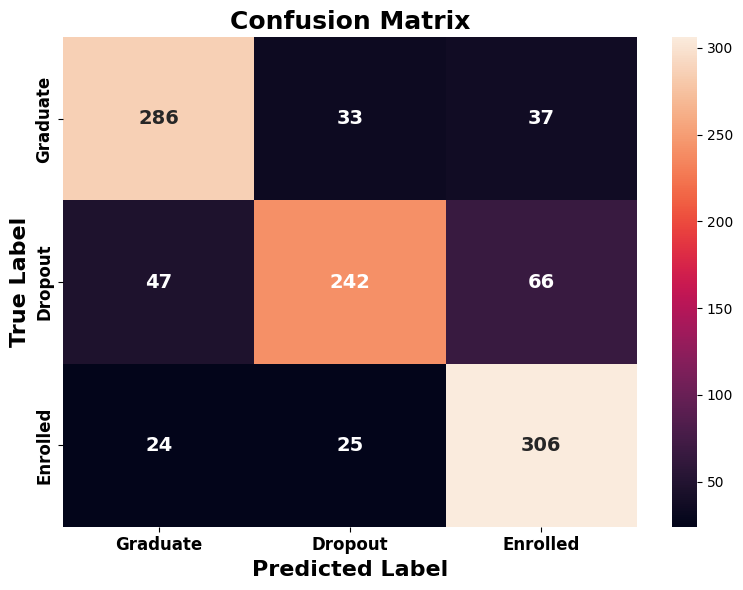

In [ ]:
y_pred_test = tree_model.predict(X_test)
evaluating(y_pred=y_pred_test, y_true=y_test)

              precision    recall  f1-score   support

     Dropout       0.89      0.73      0.80       355
    Enrolled       0.78      0.88      0.83       355
    Graduate       0.84      0.87      0.85       356

    accuracy                           0.83      1066
   macro avg       0.83      0.83      0.83      1066
weighted avg       0.83      0.83      0.83      1066



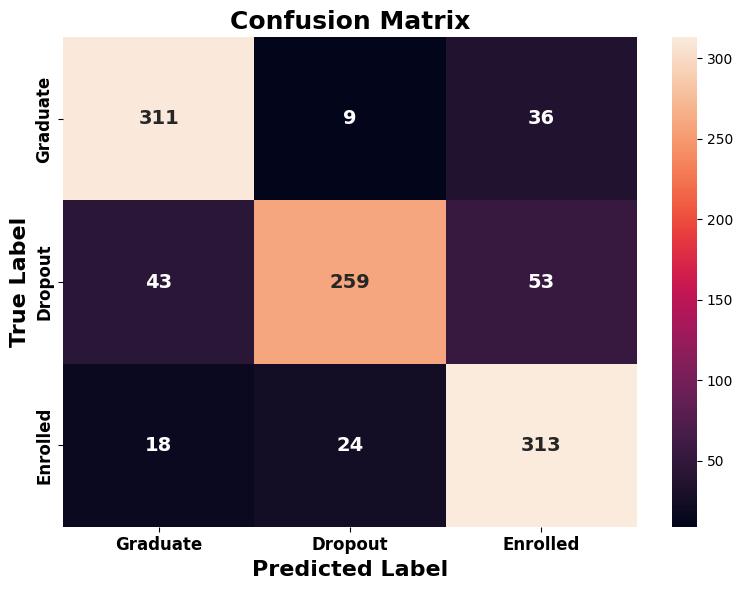

In [ ]:
y_pred_test = RFmodel.predict(X_test)
evaluating(y_pred=y_pred_test, y_true=y_test)

              precision    recall  f1-score   support

     Dropout       0.86      0.74      0.79       355
    Enrolled       0.78      0.85      0.82       355
    Graduate       0.81      0.86      0.83       356

    accuracy                           0.82      1066
   macro avg       0.82      0.82      0.81      1066
weighted avg       0.82      0.82      0.81      1066



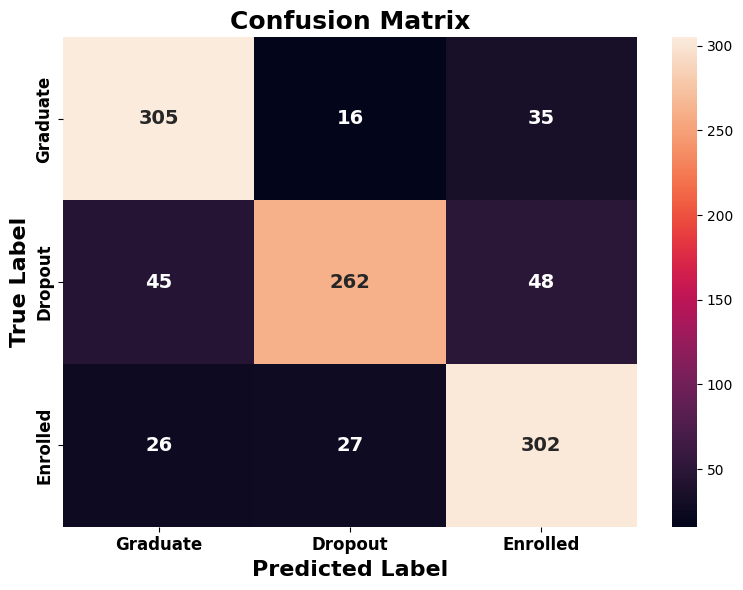

In [ ]:
y_pred_test = gboost_model.predict(X_test)
evaluating(y_pred=y_pred_test, y_true=y_test)

Berdasarkan hasil visualisasi di atas, sebenarnya tidak ada model yang cukup akurat untuk memprediksi apakah siswa itu akan graduate, dropout, ataupun enrolled. Bahkan, ketiga model tersebut masih banyak yang mengklasifikasikan siswa yang sebenarnya dropout sebagai siswa yang graduate. Tentu ini akan cukup berimbas pada kesalahan tindakan yang akan dilakukan jika siswa yang sebenarnya dropout namun malah diklasifikasikan sebagai siswa yang graduate.

In [ ]:
!pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.6.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.15
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.23
albumentations==2.0.5
ale-py==0.10.2
altair==5.5.0
annotated-types==0.7.0
anyio==4.9.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.7.1
arviz==0.21.0
astropy==7.0.1
astropy-iers-data==0.2025.4.21.0.37.6
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.1.0
bigquery-magics==0.9.0
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blosc2==3.3.1
bokeh==3.7.2
Bottleneck==1.4.2
bqplot==0.12.44
branca==0.8.1
build==1.2.2.post1
CacheControl==0.14.2
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.1.31
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.1
chex==0.1.89
clarabel==0.10.0
click==8.1.8
cloudpathlib==0.21.0
cloudpickle==3.1.1
cmake==3.31.6
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
communi

In [ ]:
!pip freeze > requirements.txt